# Phase 5 submission: Multiphase Training using Harvard Dataset
# Areeba Naveed (27100239) and Haider Wajahat (27100252)

This is our basic implementation of multi-class liver/tumor segmentation model using all available multiphase inputs.

Basic go through for this notebook:
- It uses **all four phases** in fixed order: `NC`, `AP`, `PVP`, `DP`
- It builds a **3-class target**: `0=background`, `1=liver`, `2=tumor`
- It perfroms liver/tumor segmentation and reports **both liver Dice and tumor Dice**

### Runtime Setup and Package Installation

- **Purpose:** Prepare the Colab runtime before any data or model code is used.
- **What this cell does:**
  - Mounts Google Drive so the dataset and exports can be accessed.
  - Installs the external Python packages needed for medical-image loading, preprocessing, plotting, and progress tracking.
- **Why this matters:** If the environment is not prepared first, later cells may fail because files or packages will be missing.


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Drive mount skipped or already mounted:', e)

import subprocess
import sys

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', 'nibabel', 'scipy', 'scikit-image', 'matplotlib', 'tqdm'],
    check=False,
)

print('Dependency install step finished.')


Mounted at /content/drive
Dependency install step finished.


## Import Libraries

- **Purpose:** Load all Python libraries used throughout the notebook.
- **What this cell does:**
  - Imports tools for file handling, archive extraction, and JSON saving.
  - Imports medical-imaging libraries such as `nibabel` for NIfTI volumes.
  - Imports PyTorch utilities for datasets, dataloaders, training, and model building.
- **Why this matters:** These imports support the full pipeline from raw CT archives to final segmentation results.


In [2]:
import os
import json
import tarfile
import shutil
import random
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TF

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

MODEL_VARIANT = 'dependency'
EXPERIMENT_TAG = 'p100_25d_liver_constrained_v3'
NUM_CLASSES = 3   # 0=background, 1=liver, 2=tumor
PHASE_ORDER = ['nc', 'ap', 'pvp', 'dp']
SLICE_CONTEXT_RADIUS = 1
SLICES_PER_PHASE = 2 * SLICE_CONTEXT_RADIUS + 1
IN_CHANNELS = len(PHASE_ORDER) * SLICES_PER_PHASE
IMG_SIZE = 256
BATCH_SIZE = 8
NUM_WORKERS = 2
NUM_EPOCHS = 24
EARLY_STOP_PATIENCE = 5
MIN_DELTA = 1e-4
LR = 1e-4
WEIGHT_DECAY = 1e-3
VAL_FRAC = 0.15
TEST_FRAC = 0.15
PHASE_DROPOUT_PROB = 0.03
MAX_TARS = 100
MAX_TUMOR_SLICES = 96
MAX_LIVER_CONTEXT_SLICES = 32
TUMOR_CONTEXT_RADIUS = 3
TUMOR_OVERSAMPLE_WEIGHT = 12.0
TUMOR_THRESHOLD_GRID = [0.20, 0.24, 0.28, 0.32, 0.36, 0.40, 0.44]
LIVER_THRESHOLD_GRID = [0.40, 0.45, 0.50]
MIN_TUMOR_PIXELS_GRID = [4, 8, 16, 32]
VAL_INFERENCE_TUNING = True
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Use your MyDrive shortcut folder as the single source of truth
MYDRIVE_ROOT = '/content/drive/MyDrive'
TAR_SOURCE_DIR = '/content/drive/MyDrive/MCT_LTDiag/v_download'

# Stage TARs and all heavy processing locally in the runtime
WORK_ROOT = '/content/harvard_multiphase_work'
LOCAL_TAR_ROOT = os.path.join(WORK_ROOT, 'local_tars')
EXTRACT_ROOT = os.path.join(WORK_ROOT, 'extracted_patients')
CACHE_ROOT = os.path.join(WORK_ROOT, 'processed_cache_100_multiclass_25d_liver_constrained_v3')
MULTI_CACHE = os.path.join(CACHE_ROOT, 'multiphase_mc_25d_slices_100')
ARTIFACT_DIR = os.path.join(CACHE_ROOT, 'training_artifacts')
CACHE_MANIFEST_PATH = os.path.join(MULTI_CACHE, 'cache_manifest.json')
USING_EXISTING_NPZ_CACHE = False
DISCOVERED_CACHE_ROOT = None
RAW_ARCHIVE_PATHS = []

# Optional export folder on Drive for copying final results later
DRIVE_EXPORT_ROOT = '/content/drive/MyDrive/MCT_LTDiag/final_exports'

VALID_EXTS = ('.nii', '.nii.gz')

Path(WORK_ROOT).mkdir(parents=True, exist_ok=True)
Path(LOCAL_TAR_ROOT).mkdir(parents=True, exist_ok=True)
Path(EXTRACT_ROOT).mkdir(parents=True, exist_ok=True)
Path(MULTI_CACHE).mkdir(parents=True, exist_ok=True)
Path(ARTIFACT_DIR).mkdir(parents=True, exist_ok=True)

print('Device         :', DEVICE)
print('MODEL_VARIANT  :', MODEL_VARIANT)
print('EXPERIMENT_TAG :', EXPERIMENT_TAG)
print('NUM_CLASSES    :', NUM_CLASSES)
print('IN_CHANNELS    :', IN_CHANNELS, f'({len(PHASE_ORDER)} phases x {SLICES_PER_PHASE} slices)')
print('MAX_TARS       :', MAX_TARS)
print('MYDRIVE_ROOT   :', MYDRIVE_ROOT)
print('TAR_SOURCE_DIR :', TAR_SOURCE_DIR)
print('Source exists  :', os.path.exists(TAR_SOURCE_DIR))
print('WORK_ROOT      :', WORK_ROOT)
print('LOCAL_TAR_ROOT :', LOCAL_TAR_ROOT)
print('MULTI_CACHE    :', MULTI_CACHE)
print('ARTIFACT_DIR   :', ARTIFACT_DIR)


Device         : cuda
MODEL_VARIANT  : dependency
EXPERIMENT_TAG : p100_25d_liver_constrained_v3
NUM_CLASSES    : 3
IN_CHANNELS    : 12 (4 phases x 3 slices)
MAX_TARS       : 100
MYDRIVE_ROOT   : /content/drive/MyDrive
TAR_SOURCE_DIR : /content/drive/MyDrive/MCT_LTDiag/v_download
Source exists  : False
WORK_ROOT      : /content/harvard_multiphase_work
LOCAL_TAR_ROOT : /content/harvard_multiphase_work/local_tars
MULTI_CACHE    : /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/multiphase_mc_25d_slices_100
ARTIFACT_DIR   : /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/training_artifacts


### Directory Management Utilities

- **Purpose:** Create and maintain the folder structure used by the notebook.
- **What this cell does:**
  - Defines helper functions to create folders safely.
  - Prepares local runtime folders for staged archives, extracted patients, processed cache files, and saved training artifacts.
- **Why this matters:** A clear folder structure keeps the workflow organized and prevents path-related errors later.


In [3]:
#Create a directory if it does not already exist and return the path.
def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)
    return path

#Prepare all local runtime folders used for staged TARs, extraction, cache files, and artifacts.
def reset_local_workdirs():
    ensure_dir(WORK_ROOT)
    ensure_dir(LOCAL_TAR_ROOT)
    ensure_dir(EXTRACT_ROOT)
    ensure_dir(MULTI_CACHE)
    ensure_dir(ARTIFACT_DIR)

reset_local_workdirs()
print('Local working directories are ready.')


Local working directories are ready.


## Drive Access and TAR File Discovery

- **Purpose:** Locate the dataset reliably, even if Google Drive is mounted in different ways.
- **What this cell does:**
  - Checks mounted Drive locations.
  - Searches for raw patient archives and, if needed, existing cached `.npz` slices.
  - Copies archives from Drive into local runtime storage for faster and safer processing.
- **Why this matters:** This makes the notebook more robust during long Colab sessions and reduces failures caused by unstable Drive connections.


In [4]:
#Mount or remount Google Drive so the data folder remains readable during long runs.
def mount_drive_if_needed(force=False):
    try:
        from google.colab import drive as colab_drive
        colab_drive.mount('/content/drive', force_remount=force)
    except Exception as e:
        print('Drive mount helper:', e)


ARCHIVE_EXTS = ('.tar', '.tar.gz', '.tgz', '.zip')
DRIVE_MOUNT_ROOT = '/content/drive'


def list_dir_preview(path, max_items=30):
    print('Path exists:', os.path.exists(path), '|', path)
    if os.path.exists(path):
        try:
            items = sorted(os.listdir(path))
            print('Item count :', len(items))
            for item in items[:max_items]:
                print(' ', item)
        except Exception as e:
            print('Could not list path:', e)


def drive_roots():
    roots = []
    for root in [
        MYDRIVE_ROOT,
        '/content/drive/My Drive',
        '/content/drive/MyDrive',
        '/content/drive/Shareddrives',
        '/content/drive/Shared drives',
        DRIVE_MOUNT_ROOT,
    ]:
        if root and os.path.exists(root) and root not in roots:
            roots.append(root)
    return roots


#Recursively collect raw Harvard archive files from a folder.
def find_archive_files(root_dir, max_files=None):
    archive_paths = []
    if not root_dir or not os.path.exists(root_dir):
        return archive_paths
    for root, _, files in os.walk(root_dir):
        for f in files:
            name = f.lower()
            if name.endswith(ARCHIVE_EXTS):
                archive_paths.append(os.path.join(root, f))
                if max_files and len(archive_paths) >= max_files:
                    return sorted(archive_paths)
    return sorted(archive_paths)


#Recursively collect existing cached slice files.
def find_npz_files(root_dir, max_files=None):
    npz_paths = []
    if not root_dir or not os.path.exists(root_dir):
        return npz_paths
    for root, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith('.npz'):
                npz_paths.append(os.path.join(root, f))
                if max_files and len(npz_paths) >= max_files:
                    return sorted(npz_paths)
    return sorted(npz_paths)


#Find project folders even if Colab mounted Drive under a different root or account label.
def find_project_roots():
    wanted_names = {'mct_ltdiag', 'mct-ltdiag'}
    roots = []
    print('Mounted Drive roots:')
    for root in drive_roots():
        print(' ', root)
        list_dir_preview(root, max_items=12)

    for base in drive_roots():
        for current, dirs, _ in os.walk(base):
            depth = current[len(base):].count(os.sep)
            if depth > 4:
                dirs[:] = []
                continue
            for d in list(dirs):
                if d.lower() in wanted_names:
                    path = os.path.join(current, d)
                    if path not in roots:
                        roots.append(path)
    return roots


#Pick the cache folder with the most usable .npz files from processed_cache directories.
def discover_existing_npz_cache(project_roots):
    candidates = []
    for project_root in project_roots:
        if not os.path.exists(project_root):
            continue
        for current, dirs, _ in os.walk(project_root):
            depth = current[len(project_root):].count(os.sep)
            if depth > 4:
                dirs[:] = []
                continue
            if os.path.basename(current).startswith('processed_cache'):
                npz_paths = find_npz_files(current)
                if npz_paths:
                    parent_counts = defaultdict(int)
                    for path in npz_paths:
                        parent_counts[os.path.dirname(path)] += 1
                    best_parent, best_count = max(parent_counts.items(), key=lambda kv: kv[1])
                    selected = sorted([p for p in npz_paths if os.path.dirname(p) == best_parent])
                    candidates.append((best_count, best_parent, selected))
                    print(f'Existing cache candidate: {best_parent} | npz={best_count}')

    if not candidates:
        return None, []
    candidates.sort(reverse=True, key=lambda x: x[0])
    return candidates[0][1], candidates[0][2]


#Search every mounted Drive root for raw archives or existing processed cache.
def discover_data_sources():
    explicit_project_roots = [
        os.path.join(root, 'MCT_LTDiag') for root in drive_roots()
    ] + [
        os.path.join(root, 'MCT-LTDiag') for root in drive_roots()
    ]
    discovered_project_roots = find_project_roots()
    project_roots = []
    for root in explicit_project_roots + discovered_project_roots:
        if root not in project_roots:
            project_roots.append(root)

    print('\\nProject root candidates:')
    for root in project_roots:
        list_dir_preview(root, max_items=12)

    candidate_archive_roots = [TAR_SOURCE_DIR]
    for project_root in project_roots:
        candidate_archive_roots.extend([
            os.path.join(project_root, 'v_download'),
            project_root,
        ])
    candidate_archive_roots.extend(drive_roots())

    found_archives = []
    seen_roots = set()
    for root in candidate_archive_roots:
        if root in seen_roots:
            continue
        seen_roots.add(root)
        paths = find_archive_files(root, max_files=MAX_TARS)
        print(f'Checked archive root: {root} | found {len(paths)}')
        found_archives.extend(paths)
        found_archives = sorted(dict.fromkeys(found_archives))
        if len(found_archives) >= MAX_TARS:
            break

    if found_archives:
        return 'archives', found_archives[:MAX_TARS], None, []

    print('\\nNo raw archives found. Looking for existing processed_cache*.npz slices instead...')
    cache_dir, npz_paths = discover_existing_npz_cache(project_roots)
    if cache_dir and npz_paths:
        return 'npz_cache', [], cache_dir, npz_paths

    print('\\nFinal fallback: scanning all mounted Drive roots for any .npz cache files...')
    npz_candidates = []
    for root in drive_roots():
        npz_candidates.extend(find_npz_files(root, max_files=200000))
    if npz_candidates:
        parent_counts = defaultdict(int)
        for path in npz_candidates:
            parent_counts[os.path.dirname(path)] += 1
        best_parent, best_count = max(parent_counts.items(), key=lambda kv: kv[1])
        selected = sorted([p for p in npz_candidates if os.path.dirname(p) == best_parent])
        print(f'Fallback NPZ cache candidate: {best_parent} | npz={best_count}')
        return 'npz_cache', [], best_parent, selected

    return 'none', [], None, []


#Copy one archive from Drive to local runtime with retry logic because Drive mounts can disconnect mid-copy.
def safe_copy_archive(src_path, dst_path, max_retries=4, sleep_seconds=3):
    for attempt in range(1, max_retries + 1):
        try:
            if os.path.exists(dst_path) and os.path.getsize(dst_path) > 0:
                try:
                    if os.path.getsize(src_path) == os.path.getsize(dst_path):
                        return dst_path
                except Exception:
                    pass

            shutil.copy2(src_path, dst_path)
            if not os.path.exists(dst_path) or os.path.getsize(dst_path) == 0:
                raise OSError(f'Local copy failed for {dst_path}')
            return dst_path
        except Exception as e:
            if os.path.exists(dst_path):
                try:
                    os.remove(dst_path)
                except Exception:
                    pass

            if attempt == max_retries:
                raise

            print(f'Copy retry {attempt}/{max_retries - 1} for {os.path.basename(src_path)} due to: {e}')
            time.sleep(sleep_seconds)
            mount_drive_if_needed(force=True)


#Backward compatible name used by older cells.
def safe_copy_tar(src_path, dst_path, max_retries=4, sleep_seconds=3):
    return safe_copy_archive(src_path, dst_path, max_retries=max_retries, sleep_seconds=sleep_seconds)


mount_drive_if_needed(force=False)
data_mode, archive_source_paths, cache_dir, cache_npz_paths = discover_data_sources()

USING_EXISTING_NPZ_CACHE = data_mode == 'npz_cache'
DISCOVERED_CACHE_ROOT = cache_dir
RAW_ARCHIVE_PATHS = list(archive_source_paths)

if data_mode == 'archives':
    if len(archive_source_paths) < MAX_TARS:
        print(f'Warning: requested {MAX_TARS} archives but found {len(archive_source_paths)}. Continuing with all available archives.')
    print('\\nUsing raw archives:', len(archive_source_paths))
    print('First 5 archives:')
    for p in archive_source_paths[:5]:
        print(' ', p)

    local_tar_paths = []
    for i, src_path in enumerate(archive_source_paths, start=1):
        dst_path = os.path.join(LOCAL_TAR_ROOT, os.path.basename(src_path))
        print(f'[{i:02d}/{len(archive_source_paths)}] Staging {os.path.basename(src_path)}')
        safe_copy_archive(src_path, dst_path)
        local_tar_paths.append(dst_path)

    tar_paths = list(local_tar_paths)
    tar_files = [os.path.basename(p) for p in tar_paths]

elif data_mode == 'npz_cache':
    print('\\nUsing existing NPZ cache because raw archives were not visible from Colab.')
    print('Selected NPZ cache:', DISCOVERED_CACHE_ROOT)
    print('Cached slices     :', len(cache_npz_paths))
    print('First 5 cache files:')
    for p in cache_npz_paths[:5]:
        print(' ', p)

    MULTI_CACHE = DISCOVERED_CACHE_ROOT
    CACHE_MANIFEST_PATH = os.path.join(MULTI_CACHE, 'cache_manifest.json')
    tar_paths = []
    tar_files = []

else:
    raise RuntimeError(
        'No archives or .npz caches were visible under /content/drive. This usually means Colab is mounted to a different Google account than the Drive tab showing MCT_LTDiag.'
    )

print('\\nData mode       :', data_mode)
print('Local TAR root  :', LOCAL_TAR_ROOT)
print('Staged archives :', len(tar_paths))
print('Active cache dir:', MULTI_CACHE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted Drive roots:
  /content/drive/MyDrive
Path exists: True | /content/drive/MyDrive
Item count : 192
  (3).gdoc
  17-10-22
  261.gsheet
  27020343 A5 sociology.gdoc
  27020343 Final.gdoc
  27020343 Response Paper .gdoc
  27020343 written Cp.gdoc
  27020343-2.gdoc
  27020343.gdoc
  27020343_PS9.gsheet
  27020343_final w o grammarly.gdoc
  27020521_Final.gdoc
  /content/drive/My Drive
Path exists: True | /content/drive/My Drive
Item count : 192
  (3).gdoc
  17-10-22
  261.gsheet
  27020343 A5 sociology.gdoc
  27020343 Final.gdoc
  27020343 Response Paper .gdoc
  27020343 written Cp.gdoc
  27020343-2.gdoc
  27020343.gdoc
  27020343_PS9.gsheet
  27020343_final w o grammarly.gdoc
  27020521_Final.gdoc
  /content/drive
Path exists: True | /content/drive
Item count : 4
  .Encrypted
  .Trash-0
  .shortcut-targets-by-id
  MyDrive
\nProject root candidates:
Path e

## File Parsing, Phase Identification, and Patient Extraction

- **Purpose:** Teach the notebook how to understand one patient archive.
- **What this cell does:**
  - Extracts one patient archive into a temporary folder.
  - Finds all CT and mask files inside that folder.
  - Identifies which image belongs to each CT phase and which mask belongs to liver or tumor.
- **Why this matters:** Correct phase and mask matching is essential before any preprocessing or training can be trusted.


In [5]:
import zipfile

SEG_KEYWORDS = ['seg', 'mask', 'label', 'annotation', 'contour', 'tumor', 'lesion', 'gt']
PHASE_KEYWORDS = {
    'nc':  ['_nc', 'noncontrast', 'non-contrast', 'plain', ' nc', 'nc.'],
    'ap':  ['_ap', 'arterial', ' art', 'art.', ' ap', 'ap.'],
    'pvp': ['_pvp', 'portal', 'venous', ' pv', 'pvp.'],
    'dp':  ['_dp', 'delay', 'delayed', 'equilibrium', ' dp', 'dp.'],
}

#Extract one patient archive into a temporary local folder for inspection or cache generation.
def extract_one_archive(archive_path, extract_root=EXTRACT_ROOT):
    archive_name = os.path.basename(archive_path)
    patient_name = archive_name
    for suffix in ['.tar.gz', '.tgz', '.tar', '.zip']:
        if patient_name.lower().endswith(suffix):
            patient_name = patient_name[:-len(suffix)]
            break
    patient_path = os.path.join(extract_root, patient_name)

    if os.path.exists(patient_path):
        shutil.rmtree(patient_path)
    os.makedirs(patient_path, exist_ok=True)

    lower = archive_name.lower()
    if lower.endswith('.zip'):
        with zipfile.ZipFile(archive_path, 'r') as zf:
            zf.extractall(patient_path)
    else:
        mode = 'r:gz' if lower.endswith(('.tar.gz', '.tgz')) else 'r'
        with tarfile.open(archive_path, mode) as tar:
            try:
                tar.extractall(path=patient_path, filter='data')
            except TypeError:
                tar.extractall(path=patient_path)

    return patient_name, patient_path


#Backward compatible name used by older notebook cells.
def extract_one_tar(tar_path, extract_root=EXTRACT_ROOT):
    return extract_one_archive(tar_path, extract_root=extract_root)


#Remove a temporary extracted patient folder to keep runtime storage under control.
def cleanup_patient(patient_path):
    if patient_path is not None and os.path.exists(patient_path):
        shutil.rmtree(patient_path)


#Collect all NIfTI files under the extracted patient tree.
def find_all_nifti_files(patient_path):
    found = []
    for root, _, files in os.walk(patient_path):
        for f in files:
            lower = f.lower()
            if lower.endswith(VALID_EXTS):
                found.append(os.path.join(root, f))
    return sorted(found)


#Heuristically identify whether a file is a segmentation/annotation file.
def is_seg_file(path):
    name = os.path.basename(path).lower()
    return any(k in name for k in SEG_KEYWORDS)


#Infer the CT phase label from the filename using dataset-specific naming patterns.
def infer_phase(path):
    name = os.path.basename(path).lower()
    for phase, keys in PHASE_KEYWORDS.items():
        if any(k in name for k in keys):
            return phase
    if 'portal' in name or 'venous' in name:
        return 'pvp'
    if 'arter' in name:
        return 'ap'
    if 'delay' in name or 'equilibrium' in name:
        return 'dp'
    if 'non' in name or 'plain' in name:
        return 'nc'
    return None


#Separate tumor and liver masks from the extracted segmentation files.
def identify_masks(seg_candidates):
    tumor_mask = None
    liver_mask = None
    for p in seg_candidates:
        name = os.path.basename(p).lower()
        if 'liver' in name and 'mask' in name:
            liver_mask = p
        elif ('tumor' in name or 'lesion' in name or 'mask_pvp' in name or name.startswith('mask')) and 'liver' not in name:
            tumor_mask = p
    return tumor_mask, liver_mask


#Organize one extracted patient into phase images, masks, and unassigned files.
def group_patient_files(patient_path):
    files = find_all_nifti_files(patient_path)
    seg_candidates = [p for p in files if is_seg_file(p)]
    img_candidates = [p for p in files if not is_seg_file(p)]

    tumor_mask, liver_mask = identify_masks(seg_candidates)
    phase_map = {}
    unassigned = []

    for p in img_candidates:
        phase = infer_phase(p)
        if phase is None:
            unassigned.append(p)
        else:
            phase_map[phase] = p

    return {
        'all_files': files,
        'tumor_mask': tumor_mask,
        'liver_mask': liver_mask,
        'phase_map': phase_map,
        'unassigned_images': unassigned,
    }


#Load a medical volume with nibabel and return it as a NumPy array.
def load_volume(path):
    return nib.load(path).get_fdata()


#Print a quick human-readable summary of one patient archive to verify file mapping.
def summarize_patient(archive_name):
    patient_path = None
    try:
        patient_name, patient_path = extract_one_archive(archive_name)
        info = group_patient_files(patient_path)
        print('Patient:', patient_name)
        print('Tumor mask:', os.path.basename(info['tumor_mask']) if info['tumor_mask'] else None)
        print('Liver mask:', os.path.basename(info['liver_mask']) if info['liver_mask'] else None)
        print('Phase map:')
        for k in PHASE_ORDER:
            print(f'  {k}:', os.path.basename(info['phase_map'][k]) if k in info['phase_map'] else None)
        print('Unassigned images:', [os.path.basename(p) for p in info['unassigned_images']])
        return patient_name, info
    finally:
        cleanup_patient(patient_path)


### Quick Patient Mapping Check

- **Purpose:** Confirm that the archive-reading logic is working correctly on real examples.
- **What this cell does:**
  - Prints a short summary for a few sample patients.
  - Shows the detected tumor mask, liver mask, and CT phase files.
- **Why this matters:** This is an early sanity check before heavy preprocessing begins.


In [6]:
for tar_path in tar_paths[:3]:
    summarize_patient(tar_path)
    print('-' * 80)

Patient: 230218a1
Tumor mask: mask_pvp.nii.gz
Liver mask: liver_mask_pvp.nii.gz
Phase map:
  nc: nc.nii.gz
  ap: art.nii.gz
  pvp: pvp.nii.gz
  dp: delay.nii.gz
Unassigned images: []
--------------------------------------------------------------------------------
Patient: 230218a10
Tumor mask: mask_pvp.nii.gz
Liver mask: liver_mask_pvp.nii.gz
Phase map:
  nc: nc.nii.gz
  ap: art.nii.gz
  pvp: pvp.nii.gz
  dp: delay.nii.gz
Unassigned images: []
--------------------------------------------------------------------------------
Patient: 230218a2
Tumor mask: mask_pvp.nii.gz
Liver mask: liver_mask_pvp.nii.gz
Phase map:
  nc: nc.nii.gz
  ap: art.nii.gz
  pvp: pvp.nii.gz
  dp: delay.nii.gz
Unassigned images: []
--------------------------------------------------------------------------------


### CT Normalization, Resizing, and Slice Selection Utilities

- **Purpose:** Define the core preprocessing steps applied to the CT data and masks.
- **What this cell does:**
  - Normalizes CT intensity values into a stable learning range.
  - Resizes 2D images and masks to the model input size.
  - Builds the 3-class segmentation mask: background, liver, and tumor.
  - Selects the most useful slices, especially tumor slices and nearby liver context.
- **Why this matters:** Good preprocessing improves training stability and focuses the model on informative anatomy.


In [7]:
#Clip and normalize CT intensities to a stable learning range.
def normalize_ct(vol, clip_min=-200, clip_max=250):
    vol = np.clip(vol, clip_min, clip_max)
    vol = (vol - clip_min) / (clip_max - clip_min + 1e-8)
    return vol.astype(np.float32)


#Resize a 2D image or mask slice to the model input size.
def resize_2d(arr, size=IMG_SIZE, is_mask=False):
    arr = arr.astype(np.float32)
    zoom_h = size / arr.shape[0]
    zoom_w = size / arr.shape[1]
    order = 0 if is_mask else 1
    out = zoom(arr, (zoom_h, zoom_w), order=order)
    if is_mask:
        out = np.rint(out).astype(np.uint8)
    return out


#Merge liver and tumor labels into a three-class mask used for training.
def build_multiclass_mask(liver_mask, tumor_mask):
    liver_bin = (liver_mask > 0).astype(np.uint8)
    tumor_bin = (tumor_mask > 0).astype(np.uint8)
    merged = np.zeros_like(liver_bin, dtype=np.uint8)
    merged[liver_bin > 0] = 1
    merged[tumor_bin > 0] = 2
    return merged


#Check that all phases and masks share the same spatial shape before caching.
def validate_case_geometry(phase_vols, tumor_mask, liver_mask):
    ref_phase = 'pvp' if 'pvp' in phase_vols else list(phase_vols.keys())[0]
    ref_shape = phase_vols[ref_phase].shape
    same_shape = all(vol.shape == ref_shape for vol in phase_vols.values())
    masks_match = tumor_mask.shape == ref_shape and liver_mask.shape == ref_shape
    return same_shape and masks_match, ref_shape


#Keep all tumor-bearing slices when possible and add adjacent liver context.
def select_slice_indices(
    multiclass_mask,
    max_tumor=MAX_TUMOR_SLICES,
    max_liver_only=MAX_LIVER_CONTEXT_SLICES,
    context_radius=TUMOR_CONTEXT_RADIUS,
):
    tumor_pixels = np.sum(multiclass_mask == 2, axis=(0, 1))
    liver_pixels = np.sum(multiclass_mask > 0, axis=(0, 1))
    depth = multiclass_mask.shape[2]

    tumor_idx = np.where(tumor_pixels > 0)[0].tolist()
    if len(tumor_idx) > max_tumor:
        ranked = sorted(tumor_idx, key=lambda z: tumor_pixels[z], reverse=True)
        keep_top = ranked[:max(1, int(max_tumor * 0.70))]
        remaining = sorted(set(tumor_idx) - set(keep_top))
        if remaining:
            uniform_positions = np.linspace(0, len(remaining) - 1, max_tumor - len(keep_top), dtype=int)
            keep_uniform = [remaining[pos] for pos in uniform_positions]
        else:
            keep_uniform = []
        tumor_idx = sorted(set(keep_top + keep_uniform))[:max_tumor]

    tumor_context = set(tumor_idx)
    for z in tumor_idx:
        for dz in range(-context_radius, context_radius + 1):
            zz = z + dz
            if 0 <= zz < depth and liver_pixels[zz] > 0:
                tumor_context.add(zz)

    liver_only_idx = [
        z for z in np.where(liver_pixels > 0)[0].tolist()
        if tumor_pixels[z] == 0 and z not in tumor_context
    ]
    rng = random.Random(SEED + depth + int(tumor_pixels.sum()))
    rng.shuffle(liver_only_idx)
    liver_only_idx = liver_only_idx[:max_liver_only]

    return sorted(tumor_context.union(liver_only_idx))


#Display a representative patient slice across phases plus liver/tumor overlays.
def visualize_sample_patient(tar_name):
    patient_path = None
    try:
        patient_name, patient_path = extract_one_tar(tar_name)
        info = group_patient_files(patient_path)

        if info['tumor_mask'] is None or info['liver_mask'] is None:
            print('Required masks missing for patient:', patient_name)
            return

        phase_vols = {phase: normalize_ct(load_volume(path)) for phase, path in info['phase_map'].items()}
        tumor_mask = load_volume(info['tumor_mask']).astype(np.uint8)
        liver_mask = load_volume(info['liver_mask']).astype(np.uint8)
        multiclass = build_multiclass_mask(liver_mask, tumor_mask)

        tumor_per_slice = np.sum(multiclass == 2, axis=(0, 1))
        z = int(np.argmax(tumor_per_slice)) if tumor_per_slice.max() > 0 else multiclass.shape[2] // 2

        fig, axes = plt.subplots(1, 6, figsize=(24, 5))
        for i, phase in enumerate(PHASE_ORDER):
            if phase in phase_vols:
                axes[i].imshow(phase_vols[phase][:, :, z], cmap='gray')
                axes[i].set_title(phase.upper())
            else:
                axes[i].text(0.5, 0.5, f'{phase.upper()} missing', ha='center', va='center')
                axes[i].set_title(phase.upper())
            axes[i].axis('off')

        base = phase_vols['pvp'] if 'pvp' in phase_vols else list(phase_vols.values())[0]
        axes[4].imshow(base[:, :, z], cmap='gray')
        axes[4].imshow((multiclass[:, :, z] == 1).astype(np.float32), alpha=0.25)
        axes[4].set_title('Liver overlay')
        axes[4].axis('off')

        axes[5].imshow(base[:, :, z], cmap='gray')
        axes[5].imshow((multiclass[:, :, z] == 2).astype(np.float32), alpha=0.35)
        axes[5].set_title('Tumor overlay')
        axes[5].axis('off')

        plt.tight_layout()
        plt.show()
    finally:
        cleanup_patient(patient_path)


### Visual Verification of One Sample Patient

- **Purpose:** Inspect one patient visually before building the reusable cache.
- **What this cell does:**
  - Displays the selected slice across all four CT phases.
  - Overlays liver and tumor regions for quick alignment checking.
- **Why this matters:** A visual check helps catch phase-order or mask-alignment issues that may not be obvious from printed text alone.


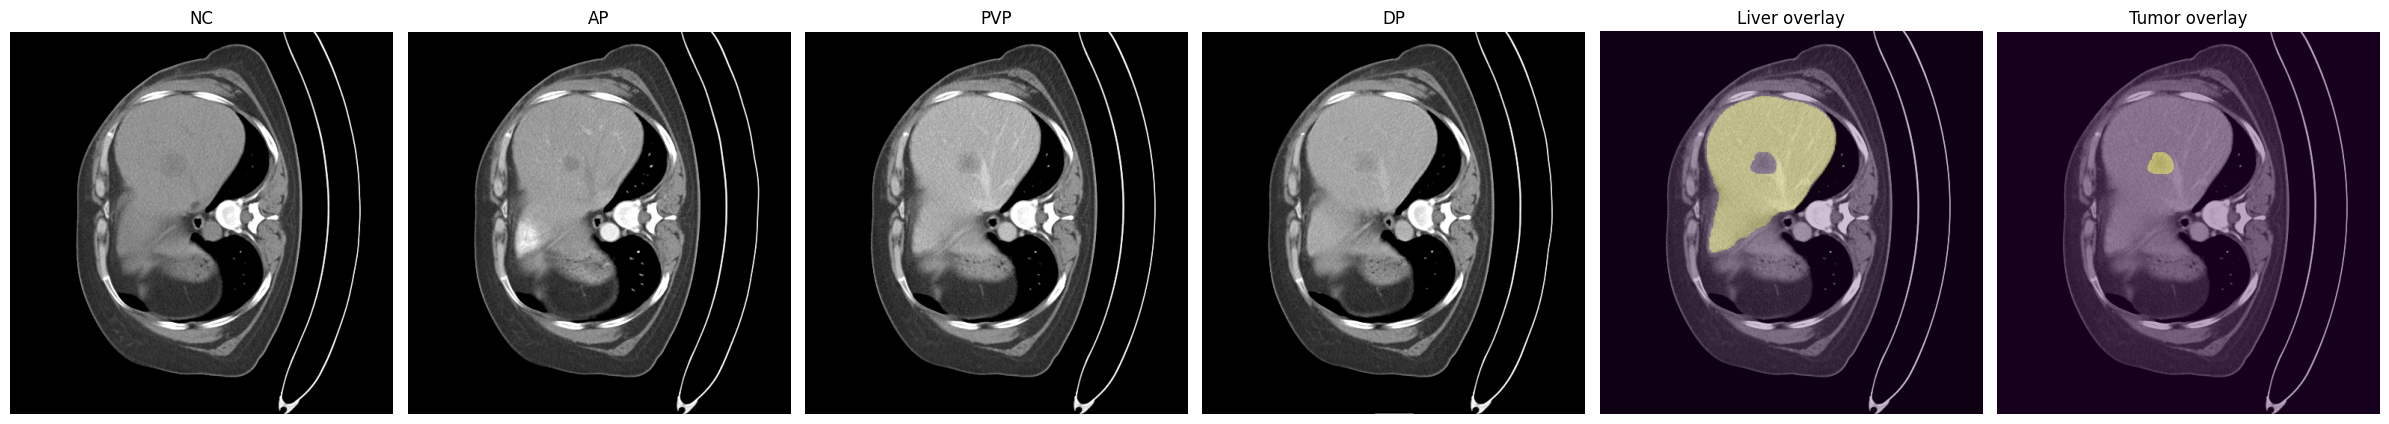

In [8]:
if len(tar_paths) == 0:
    print('No tar files available for visualization.')
else:
    visualize_sample_patient(tar_paths[0])


## 3. Build Safe Reusable Multi-Class Cache from 100 Patient Archives

This cache now includes a **manifest** so we do not accidentally reuse stale or incompatible cached slices from an older notebook version.

Each `.npz` contains:

- `image`: `(4, H, W)` in phase order `[NC, AP, PVP, DP]`
- `mask`: `(H, W)` with classes `0=background, 1=liver, 2=tumor`
- `present`: which phases are present
- `has_tumor`: whether the selected slice contains tumor
- `patient_id`, `slice_idx`

The cache converts raw patient TAR files into reusable 2D multi-phase training slices. This is the key preprocessing stage that makes the later training loop faster, more repeatable, and easier to debug.


### Cache Manifest and Cache Validation Logic

- **Purpose:** Make cached preprocessing reusable and safe.
- **What this cell does:**
  - Defines the expected cache settings for this experiment.
  - Checks whether an existing cache matches the current notebook configuration.
  - Clears old cache files if a rebuild is required.
- **Why this matters:** This avoids accidentally training on stale or incompatible preprocessed data.


In [9]:
CACHE_VERSION = 6
#Describe the cache configuration so stale cached slices can be detected safely.
def expected_cache_manifest(selected_tars):
    return {
        'cache_version': CACHE_VERSION,
        'experiment_tag': EXPERIMENT_TAG,
        'img_size': IMG_SIZE,
        'phase_order': PHASE_ORDER,
        'slice_context_radius': SLICE_CONTEXT_RADIUS,
        'slices_per_phase': SLICES_PER_PHASE,
        'in_channels': IN_CHANNELS,
        'max_tars': len(selected_tars),
        'tar_names': [os.path.basename(p) for p in selected_tars],
        'num_classes': NUM_CLASSES,
        'mask_definition': '0=background,1=liver,2=tumor',
        'max_tumor_slices': MAX_TUMOR_SLICES,
        'max_liver_context_slices': MAX_LIVER_CONTEXT_SLICES,
        'tumor_context_radius': TUMOR_CONTEXT_RADIUS,
    }


#Check whether the existing cache matches the current preprocessing settings.
def cache_is_valid(selected_tars):
    if not os.path.exists(CACHE_MANIFEST_PATH):
        return False
    try:
        with open(CACHE_MANIFEST_PATH, 'r') as f:
            manifest = json.load(f)
    except Exception:
        return False
    return manifest == expected_cache_manifest(selected_tars)
#Delete old cached files before rebuilding the slice cache.
def clear_cache_dir(cache_dir):
    if os.path.exists(cache_dir):
        for name in os.listdir(cache_dir):
            path = os.path.join(cache_dir, name)
            if os.path.isfile(path):
                os.remove(path)
            else:
                shutil.rmtree(path)
    ensure_dir(cache_dir)


#Convert raw patient volumes into reusable multi-phase 2D training slices.
def build_multiphase_cache(selected_tars, out_dir=MULTI_CACHE):
    ensure_dir(out_dir)
    ensure_dir(EXTRACT_ROOT)

    patient_slice_counts = {}
    usable_patients = 0
    failed_patients = []

    for i, tar_path in enumerate(selected_tars, start=1):
        patient_path = None
        try:
            patient_name, patient_path = extract_one_tar(tar_path)
            info = group_patient_files(patient_path)

            if info['tumor_mask'] is None or info['liver_mask'] is None:
                print(f'[{i:02d}] {patient_name}: missing required masks, skipping')
                failed_patients.append((patient_name, 'missing_masks'))
                continue

            phase_vols = {phase: load_volume(path) for phase, path in info['phase_map'].items()}
            if len(phase_vols) == 0:
                print(f'[{i:02d}] {patient_name}: no phase images found, skipping')
                failed_patients.append((patient_name, 'no_phases'))
                continue

            tumor_mask = load_volume(info['tumor_mask']).astype(np.uint8)
            liver_mask = load_volume(info['liver_mask']).astype(np.uint8)
            ok, ref_shape = validate_case_geometry(phase_vols, tumor_mask, liver_mask)
            if not ok:
                print(f'[{i:02d}] {patient_name}: geometry mismatch, skipping')
                failed_patients.append((patient_name, 'geometry_mismatch'))
                continue

            multiclass_mask = build_multiclass_mask(liver_mask, tumor_mask)
            present = [1 if p in phase_vols else 0 for p in PHASE_ORDER]
            slice_ids = select_slice_indices(multiclass_mask)
            saved_here = 0

            normalized_phase_vols = {phase: normalize_ct(vol) for phase, vol in phase_vols.items()}

            for z in slice_ids:
                img_stack = []
                for phase in PHASE_ORDER:
                    if phase in normalized_phase_vols:
                        vol = normalized_phase_vols[phase]
                        for dz in range(-SLICE_CONTEXT_RADIUS, SLICE_CONTEXT_RADIUS + 1):
                            zz = int(np.clip(z + dz, 0, vol.shape[2] - 1))
                            img2d = resize_2d(vol[:, :, zz], IMG_SIZE, is_mask=False)
                            img_stack.append(img2d)
                    else:
                        for _ in range(SLICES_PER_PHASE):
                            img_stack.append(np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32))

                img_stack = np.stack(img_stack, axis=0).astype(np.float32)
                seg2d = resize_2d(multiclass_mask[:, :, z], IMG_SIZE, is_mask=True)
                has_tumor = int(np.any(seg2d == 2))

                save_path = os.path.join(out_dir, f'{patient_name}_z{z:03d}.npz')
                np.savez_compressed(
                    save_path,
                    image=img_stack,
                    mask=seg2d.astype(np.uint8),
                    present=np.array(present, dtype=np.uint8),
                    has_tumor=np.array([has_tumor], dtype=np.uint8),
                    patient_id=patient_name,
                    slice_idx=np.array([z], dtype=np.int32),
                )
                saved_here += 1

            if saved_here > 0:
                patient_slice_counts[patient_name] = saved_here
                usable_patients += 1
                print(f'[{i:02d}] {patient_name}: saved {saved_here} slices | present={present}')
            else:
                print(f'[{i:02d}] {patient_name}: no slices saved')
                failed_patients.append((patient_name, 'no_slices_saved'))

        except Exception as e:
            print(f'[{i:02d}] Error for {tar_path}: {e}')
            failed_patients.append((os.path.basename(tar_path), str(e)))
        finally:
            cleanup_patient(patient_path)

    manifest = expected_cache_manifest(selected_tars)
    with open(CACHE_MANIFEST_PATH, 'w') as f:
        json.dump(manifest, f, indent=2)

    print('\nCache complete.')
    print('Usable patients    :', usable_patients)
    print('Total cached slices:', sum(patient_slice_counts.values()))
    print('Failed patients    :', len(failed_patients))

    if failed_patients:
        print('\nFirst 10 failures:')
        for item in failed_patients[:10]:
            print(' ', item)

    return patient_slice_counts


### Multi-Phase Cache Construction

- **Purpose:** Convert raw patient volumes into ready-to-use training samples.
- **What this cell does:**
  - Reads each patient archive.
  - Loads the CT phases and masks.
  - Applies normalization, resizing, and slice selection.
  - Saves each selected sample as a compressed `.npz` file.
- **Why this matters:** Once the cache is built, later experiments become much faster and easier to reproduce.


In [10]:
print('Cache manifest path:', CACHE_MANIFEST_PATH)

if USING_EXISTING_NPZ_CACHE:
    print('Using existing processed cache. Skipping raw archive preprocessing.')
    existing = [f for f in os.listdir(MULTI_CACHE) if f.endswith('.npz')]
    print('Cached slice files:', len(existing))
elif len(tar_paths) == 0:
    raise RuntimeError('No raw archives are staged and no existing NPZ cache was selected.')
elif not cache_is_valid(tar_paths):
    print('Cache manifest missing or stale. Rebuilding cache...')
    clear_cache_dir(MULTI_CACHE)
    patient_slice_counts = build_multiphase_cache(tar_paths, MULTI_CACHE)
else:
    existing = [f for f in os.listdir(MULTI_CACHE) if f.endswith('.npz')]
    print('Valid cache already exists. Skipping rebuild.')
    print('Cached slice files:', len(existing))


Cache manifest path: /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/multiphase_mc_25d_slices_100/cache_manifest.json
Cache manifest missing or stale. Rebuilding cache...
[01] 230218a1: saved 32 slices | present=[1, 1, 1, 1]
[02] 230218a10: saved 25 slices | present=[1, 1, 1, 1]
[03] 230218a2: saved 33 slices | present=[1, 1, 1, 1]
[04] 230218a3: saved 29 slices | present=[1, 1, 1, 1]
[05] 230218a4: saved 28 slices | present=[1, 1, 1, 1]
[06] 230218a5: saved 43 slices | present=[1, 1, 1, 1]
[07] 230218a6: saved 30 slices | present=[1, 1, 1, 1]
[08] 230218a7: saved 33 slices | present=[1, 1, 1, 1]
[09] 230218a8: saved 33 slices | present=[1, 1, 1, 1]
[10] 230218a9: saved 36 slices | present=[1, 1, 1, 1]
[11] 230218b1: saved 24 slices | present=[1, 1, 1, 1]
[12] 230218b10: saved 31 slices | present=[1, 1, 1, 1]
[13] 230218b2: saved 31 slices | present=[1, 1, 1, 1]
[14] 230218b3: saved 36 slices | present=[1, 1, 1, 1]
[15] 230218b4: saved 25 slices

### Cache Inspection and Verification

- **Purpose:** Check that the processed cache was created correctly.
- **What this cell does:**
  - Lists cached slice files.
  - Opens one sample and prints its shape and metadata.
  - Confirms the stored image channels, mask labels, patient ID, and slice index.
- **Why this matters:** This ensures that the model will be trained on correctly structured inputs.


In [11]:
npz_files = sorted([os.path.join(MULTI_CACHE, f) for f in os.listdir(MULTI_CACHE) if f.endswith('.npz')])
print('Cached slice files:', len(npz_files))

if len(npz_files) == 0:
    raise RuntimeError(f'No .npz cached slices found in active cache directory: {MULTI_CACHE}')

sample = np.load(npz_files[0], allow_pickle=True)
sample_channels = int(sample['image'].shape[0])
if sample_channels != IN_CHANNELS:
    print(f'Adapting model input channels from {IN_CHANNELS} to cache channels {sample_channels}.')
    IN_CHANNELS = sample_channels
    if IN_CHANNELS % len(PHASE_ORDER) == 0:
        SLICES_PER_PHASE = max(1, IN_CHANNELS // len(PHASE_ORDER))
        SLICE_CONTEXT_RADIUS = max(0, (SLICES_PER_PHASE - 1) // 2)
    else:
        SLICES_PER_PHASE = 1
        SLICE_CONTEXT_RADIUS = 0
    print('SLICES_PER_PHASE:', SLICES_PER_PHASE)
    print('SLICE_CONTEXT_RADIUS:', SLICE_CONTEXT_RADIUS)

print('image shape :', sample['image'].shape)
print('mask shape  :', sample['mask'].shape)
print('present     :', sample['present'] if 'present' in sample.files else 'missing')
print('has_tumor   :', sample['has_tumor'] if 'has_tumor' in sample.files else 'missing')
print('patient id  :', sample['patient_id'] if 'patient_id' in sample.files else 'missing')
print('slice idx   :', sample['slice_idx'] if 'slice_idx' in sample.files else 'missing')
print('mask labels :', np.unique(sample['mask']))


Cached slice files: 3212
image shape : (12, 256, 256)
mask shape  : (256, 256)
present     : [1 1 1 1]
has_tumor   : [0]
patient id  : 230218a10
slice idx   : [53]
mask labels : [0 1]


## Dataset Class and Patient-Wise Train/Validation/Test Split

- **Purpose:** Turn cached slices into PyTorch datasets and build leak-safe data splits.
- **What this cell does:**
  - Defines the dataset class used during training and evaluation.
  - Applies lightweight augmentation and optional phase dropout.
  - Splits data at the patient level into train, validation, and test sets.
  - Uses weighted sampling to show tumor-positive slices more often during training.
- **Why this matters:** Patient-wise splitting prevents data leakage, and tumor-aware sampling improves lesion learning.


In [12]:
#Load cached multi-phase 2D slices and apply lightweight training augmentation.
class MultiPhaseNPZDataset(Dataset):
    def __init__(self, files, phase_dropout_prob=0.0, augment=False):
        self.files = files
        self.phase_dropout_prob = phase_dropout_prob
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx], allow_pickle=True)
        image = data['image'].astype(np.float32)
        mask = data['mask'].astype(np.int64)
        present = data['present'].astype(np.float32) if 'present' in data.files else np.ones(len(PHASE_ORDER), dtype=np.float32)
        patient_id = str(data['patient_id']) if 'patient_id' in data.files else os.path.basename(self.files[idx]).split('_z')[0]
        slice_idx = int(data['slice_idx'][0]) if 'slice_idx' in data.files else idx
        has_tumor = int(data['has_tumor'][0]) if 'has_tumor' in data.files else int(np.any(mask == 2))

        if self.phase_dropout_prob > 0:
            keep = present.copy()
            channels_per_phase = max(1, image.shape[0] // max(len(present), 1))
            for phase_idx in range(len(present)):
                if keep[phase_idx] > 0 and random.random() < self.phase_dropout_prob:
                    keep[phase_idx] = 0.0
            if keep.sum() == 0:
                available = np.where(present > 0)[0]
                if len(available) > 0:
                    keep[random.choice(available)] = 1.0
            for phase_idx, phase_keep in enumerate(keep):
                start = phase_idx * channels_per_phase
                end = start + channels_per_phase
                image[start:end] *= phase_keep
            present = keep

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask.unsqueeze(0)).squeeze(0)
            # Mild intensity jitter keeps CT anatomy realistic while improving robustness.
            if random.random() > 0.5:
                factor = random.uniform(0.90, 1.10)
                image = (image * factor).clamp(0.0, 1.0)
            if random.random() > 0.7:
                bias = random.uniform(-0.03, 0.03)
                image = (image + bias).clamp(0.0, 1.0)
            if random.random() > 0.75:
                image = (image + torch.randn_like(image) * 0.01).clamp(0.0, 1.0)

        return {
            'image': image,
            'mask': mask,
            'present': torch.tensor(present, dtype=torch.float32),
            'patient_id': patient_id,
            'slice_idx': slice_idx,
            'has_tumor': has_tumor,
        }


#Create leak-safe train/val/test splits by grouping slices at the patient level.
def split_files_by_patient(npz_files, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED):
    patient_to_files = defaultdict(list)
    patient_has_tumor = defaultdict(int)
    for f in npz_files:
        data = np.load(f, allow_pickle=True)
        pid = str(data['patient_id']) if 'patient_id' in data.files else os.path.basename(f).split('_z')[0]
        has_tumor = int(data['has_tumor'][0]) if 'has_tumor' in data.files else int(np.any(data['mask'] == 2))
        patient_to_files[pid].append(f)
        patient_has_tumor[pid] = max(patient_has_tumor[pid], has_tumor)

    patients = sorted(patient_to_files.keys())
    if len(patients) < 3:
        raise RuntimeError(f'Need at least 3 patients for train/val/test split, found {len(patients)}')

    rng = random.Random(seed)
    tumor_patients = [p for p in patients if patient_has_tumor[p] == 1]
    non_tumor_patients = [p for p in patients if patient_has_tumor[p] == 0]
    rng.shuffle(tumor_patients)
    rng.shuffle(non_tumor_patients)

    def assign_group(group_patients):
        n_group = len(group_patients)
        if n_group == 0:
            return [], [], []
        n_test = int(round(n_group * test_frac))
        n_val = int(round(n_group * val_frac))
        if n_group >= 3:
            n_test = max(1, n_test)
            n_val = max(1, n_val)
        while n_test + n_val >= n_group and (n_test > 0 or n_val > 0):
            if n_test >= n_val and n_test > 0:
                n_test -= 1
            elif n_val > 0:
                n_val -= 1
        test_group = group_patients[:n_test]
        val_group = group_patients[n_test:n_test + n_val]
        train_group = group_patients[n_test + n_val:]
        return train_group, val_group, test_group

    train_t, val_t, test_t = assign_group(tumor_patients)
    train_n, val_n, test_n = assign_group(non_tumor_patients)

    train_patients = set(train_t + train_n)
    val_patients = set(val_t + val_n)
    test_patients = set(test_t + test_n)

    for split_name, split_patients in [('train', train_patients), ('val', val_patients), ('test', test_patients)]:
        if len(split_patients) == 0:
            raise RuntimeError(f'{split_name} split is empty. Adjust split fractions or cache more patients.')

    train_files, val_files, test_files = [], [], []
    for pid, files in patient_to_files.items():
        if pid in test_patients:
            test_files.extend(files)
        elif pid in val_patients:
            val_files.extend(files)
        else:
            train_files.extend(files)

    overlap = set(train_patients) & set(val_patients) | set(train_patients) & set(test_patients) | set(val_patients) & set(test_patients)
    assert len(overlap) == 0, f'Patient leakage detected: {overlap}'

    def split_summary(split_patients):
        return sum(patient_has_tumor[p] for p in split_patients), len(split_patients)

    train_tumor_pts, train_total_pts = split_summary(train_patients)
    val_tumor_pts, val_total_pts = split_summary(val_patients)
    test_tumor_pts, test_total_pts = split_summary(test_patients)
    print(f'Tumor-positive patients | train={train_tumor_pts}/{train_total_pts} | val={val_tumor_pts}/{val_total_pts} | test={test_tumor_pts}/{test_total_pts}')

    return train_files, val_files, test_files, sorted(train_patients), sorted(val_patients), sorted(test_patients)


train_files, val_files, test_files, train_patients, val_patients, test_patients = split_files_by_patient(npz_files)

print('Train patients:', len(train_patients), train_patients)
print('Val patients  :', len(val_patients), val_patients)
print('Test patients :', len(test_patients), test_patients)
print('Train slices  :', len(train_files))
print('Val slices    :', len(val_files))
print('Test slices   :', len(test_files))

train_ds = MultiPhaseNPZDataset(train_files, phase_dropout_prob=(PHASE_DROPOUT_PROB if MODEL_VARIANT == 'dependency' else 0.0), augment=True)
val_ds = MultiPhaseNPZDataset(val_files, phase_dropout_prob=0.0, augment=False)
test_ds = MultiPhaseNPZDataset(test_files, phase_dropout_prob=0.0, augment=False)
train_has_tumor = []
for f in train_files:
    data = np.load(f, allow_pickle=True)
    train_has_tumor.append(int(data['has_tumor'][0]) if 'has_tumor' in data.files else int(np.any(data['mask'] == 2)))

num_tumor_pos = sum(train_has_tumor)
num_tumor_neg = len(train_has_tumor) - num_tumor_pos
auto_tumor_weight = min(16.0, max(TUMOR_OVERSAMPLE_WEIGHT, num_tumor_neg / max(num_tumor_pos, 1)))
sample_weights = [auto_tumor_weight if flag == 1 else 1.0 for flag in train_has_tumor]
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print('Tumor-positive train slices:', num_tumor_pos)
print('Tumor-negative train slices:', num_tumor_neg)
print('Tumor sampler weight      :', round(float(auto_tumor_weight), 2))


Tumor-positive patients | train=70/70 | val=15/15 | test=15/15
Train patients: 70 ['230218a1', '230218a2', '230218a3', '230218a4', '230218a5', '230218a6', '230218a7', '230218a8', '230218b10', '230218b2', '230218b3', '230218b4', '230218b6', '230218b7', '230218b8', '230218b9', '230218c1', '230218c3', '230218c4', '230218c5', '230218c6', '230218c8', '230312a1', '230312a10', '230312a12', '230312a15', '230312a2', '230312a3', '230312a5', '230312a6', '230312a7', '230408a1', '230408a11', '230408a13', '230408a3', '230408a7', '230408a8', '230408a9', '230525a1', '230525a4', '230525a5', '230525b1', '230525b10', '230525b2', '230525b3', '230525b4', '230525b5', '230525b7', '230525b8', '230525b9', '230525c1', '230525c2', '230525c5', '230525c7', '230525c9', '230525d10', '230525d3', '230525d4', '230525d6', '230525d7', '230525d8', '230816b01', '230816b02', '230816b03', '230816b06', '230816b07', '230816b08', '230816b10', '230816b11', '230816b12']
Val patients  : 15 ['230218c10', '230218c7', '230312a11', '2

## Sample Visualization from the Prepared Dataset

- **Purpose:** Inspect the final training samples after preprocessing and dataset loading.
- **What this cell does:**
  - Shows example inputs from the prepared dataset.
  - Displays the paired masks so image-to-label alignment can be checked.
- **Why this matters:** This is a final visual sanity check before model training starts.


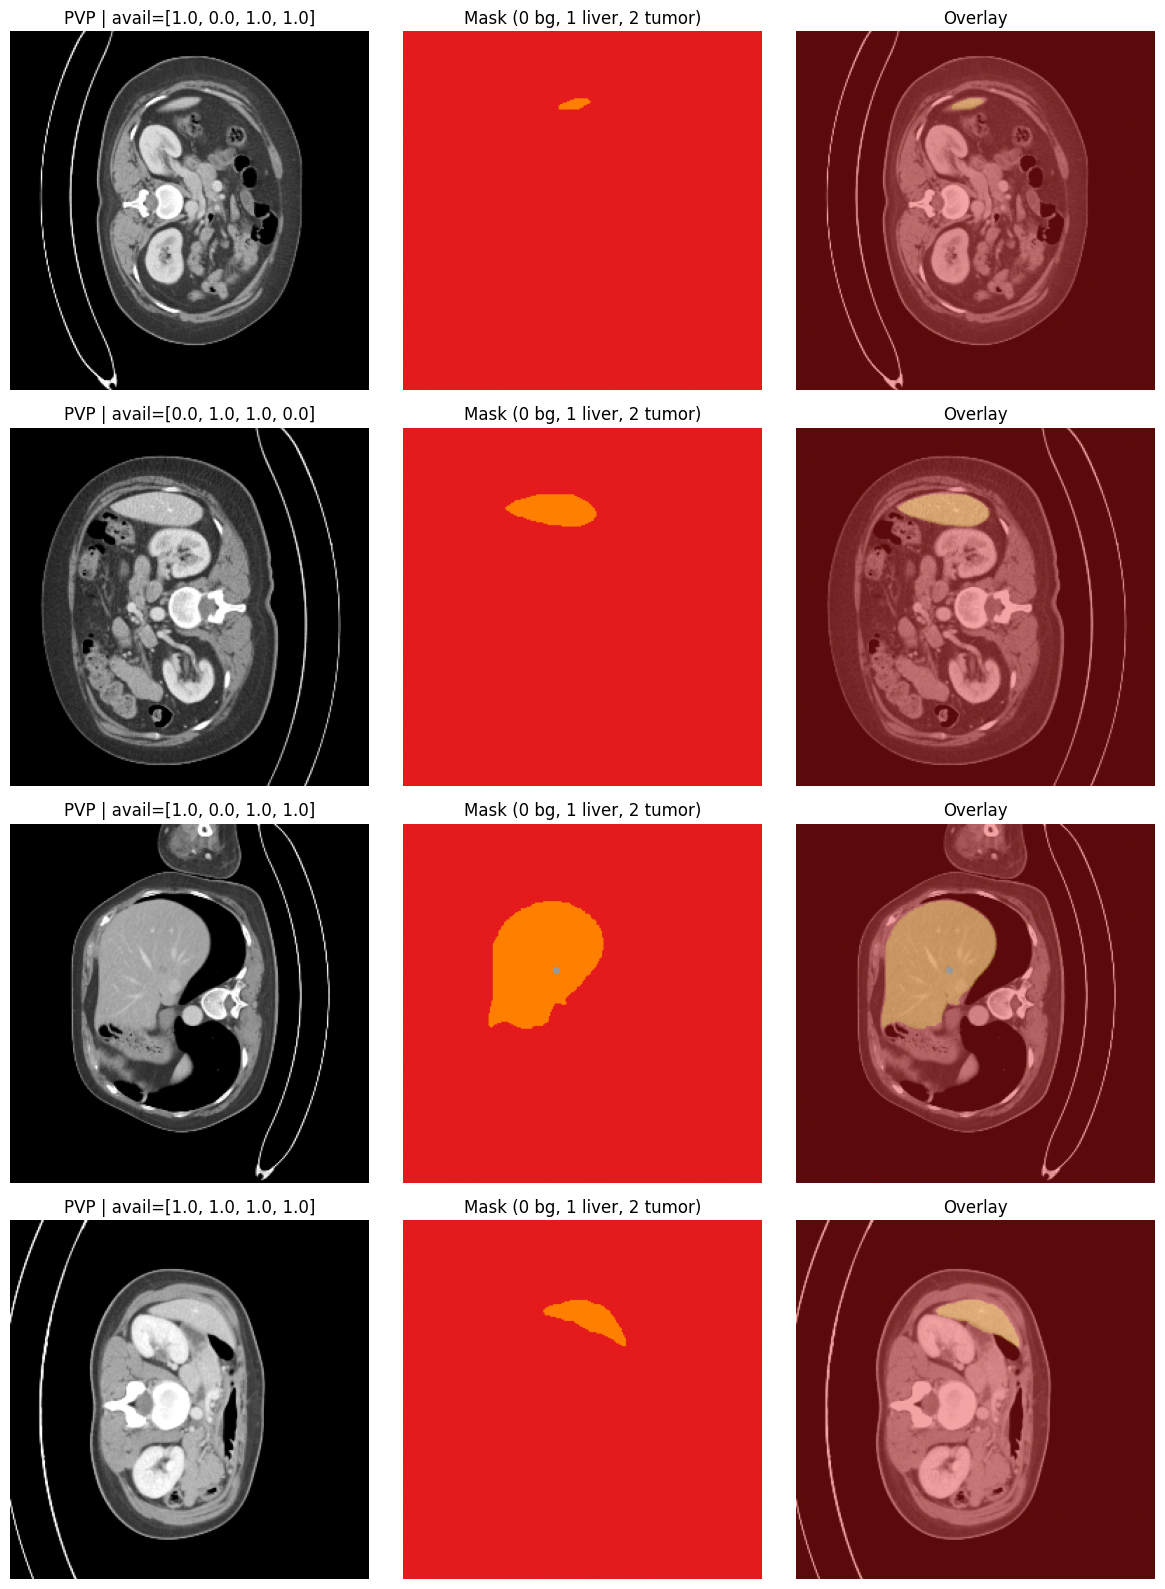

In [13]:
def plot_samples(dataset, n=4):
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    cmap_mask = plt.get_cmap('Set1', 3)

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    step = max(1, len(dataset) // n)
    for i in range(n):
        item = dataset[min(i * step, len(dataset) - 1)]
        pvp_center = PHASE_ORDER.index('pvp') * SLICES_PER_PHASE + SLICE_CONTEXT_RADIUS
        img = item['image'][pvp_center].numpy()
        msk = item['mask'].numpy()

        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(f'PVP | avail={item["present"].tolist()}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(msk, cmap=cmap_mask, vmin=0, vmax=2)
        axes[i, 1].set_title('Mask (0 bg, 1 liver, 2 tumor)')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(img, cmap='gray')
        axes[i, 2].imshow(msk, cmap=cmap_mask, alpha=0.4, vmin=0, vmax=2)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


plot_samples(train_ds, n=min(4, len(train_ds)))


### Models

- **Purpose:** Define the segmentation architectures used in this notebook.
- **What this cell does:**
  - Builds reusable encoder, decoder, attention, and convolution blocks.
  - Defines the baseline attention U-Net.
  - Defines the dependency-aware model with per-phase encoding, phase gates, and explicit phase interaction modeling.
- **Why this matters:** This cell contains the main architectural difference between the baseline design and the proposed final model.


In [14]:
#Gate skip features so the decoder focuses on the most relevant spatial signals.

class AttentionGate(nn.Module):
    def __init__(self, g_channels, x_channels, inter_channels):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_channels, inter_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_channels, inter_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


#Basic convolutional feature extractor used throughout the encoder and decoder.
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)



#Downsampling path that collects multi-scale features for segmentation.
class Encoder(nn.Module):
    def __init__(self, in_ch, features):
        super().__init__()
        self.blocks = nn.ModuleList()
        self.pools = nn.ModuleList()
        for f in features:
            self.blocks.append(ConvBlock(in_ch, f))
            self.pools.append(nn.MaxPool2d(2))
            in_ch = f

    def forward(self, x):
        skips = []
        for block, pool in zip(self.blocks, self.pools):
            x = block(x)
            skips.append(x)
            x = pool(x)
        return x, skips


#Upsampling path that combines coarse context with attention-filtered skip connections.

class AttentionDecoder(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.ups = nn.ModuleList()
        self.attn_gates = nn.ModuleList()
        self.blocks = nn.ModuleList()
        for i in range(len(features) - 1):
            ch = features[i + 1]
            self.ups.append(nn.ConvTranspose2d(features[i], ch, kernel_size=2, stride=2))
            self.attn_gates.append(AttentionGate(g_channels=ch, x_channels=ch, inter_channels=max(ch // 2, 1)))
            self.blocks.append(ConvBlock(features[i], ch))

    def forward(self, x, skips):
        skips = skips[::-1]
        for up, attn, block, skip in zip(self.ups, self.attn_gates, self.blocks, skips):
            x = up(x)
            if x.shape[2:] != skip.shape[2:]:
                x = TF.resize(x, size=skip.shape[2:])
            skip = attn(g=x, x=skip)
            x = torch.cat([skip, x], dim=1)
            x = block(x)
        return x


#Main baseline segmentation model used for the reported results in this notebook.
class BaselineAttentionUNet(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, num_classes=NUM_CLASSES, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = Encoder(in_channels, features)
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2, dropout=0.15)
        decoder_features = [features[-1] * 2] + features[::-1]
        self.decoder = AttentionDecoder(decoder_features)
        self.head = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, image, present=None):
        x, skips = self.encoder(image)
        x = self.bottleneck(x)
        x = self.decoder(x, skips)
        logits = self.head(x)
        return {'logits': logits}


#Reusable per-phase encoder for the dependency-aware model variant.
class SharedPhaseEncoder(nn.Module):
    def __init__(self, in_channels=SLICES_PER_PHASE, base_features=[48, 96, 192]):
        super().__init__()
        self.encoder = Encoder(in_channels, base_features)
        self.bottleneck = ConvBlock(base_features[-1], base_features[-1] * 2, dropout=0.15)

    def forward(self, x):
        feat, skips = self.encoder(x)
        feat = self.bottleneck(feat)
        return feat, skips


#Alternative model that fuses phase-specific features with simple dependency-aware interactions.
class DependencyAttentionUNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, num_phases=len(PHASE_ORDER), slices_per_phase=SLICES_PER_PHASE, base_features=[48, 96, 192]):
        super().__init__()
        self.num_phases = num_phases
        self.slices_per_phase = slices_per_phase
        self.phase_encoder = SharedPhaseEncoder(in_channels=slices_per_phase, base_features=base_features)
        fusion_ch = base_features[-1] * 2
        self.phase_gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(fusion_ch, fusion_ch // 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(fusion_ch // 2, 1, 1),
        )
        self.context_proj = nn.Conv2d(fusion_ch, fusion_ch, kernel_size=1)
        self.context_scale = nn.Parameter(torch.tensor(0.10))
        decoder_features = [fusion_ch] + base_features[::-1]
        self.decoder = AttentionDecoder(decoder_features)
        self.head = nn.Conv2d(base_features[0], num_classes, kernel_size=1)

    def forward(self, image, present=None):
        phase_feats, phase_skips, phase_gates = [], [], []
        for p in range(self.num_phases):
            start = p * self.slices_per_phase
            end = start + self.slices_per_phase
            feat, skips = self.phase_encoder(image[:, start:end])
            gate = torch.sigmoid(self.phase_gate(feat)) * 0.85 + 0.15  # clamp to [0.15, 1.0], prevents collapse
            if present is not None:
                gate = gate * present[:, p].view(-1, 1, 1, 1)
            phase_feats.append(feat)
            phase_skips.append(skips)
            phase_gates.append(gate)

        fused_feat = 0
        fused_skips = [0 for _ in range(len(phase_skips[0]))]
        denom = 1e-6
        for idx, feat in enumerate(phase_feats):
            gate = phase_gates[idx]
            fused_feat = fused_feat + feat * gate
            denom = denom + gate
            for s_idx, skip in enumerate(phase_skips[idx]):
                fused_skips[s_idx] = fused_skips[s_idx] + skip * gate
        fused_feat = fused_feat / denom
        fused_skips = [skip / denom for skip in fused_skips]

        pair_sum = 0
        pair_weight_sum = 0
        for i in range(self.num_phases):
            for j in range(i + 1, self.num_phases):
                pair = phase_feats[i] * phase_feats[j]
                if present is not None:
                    pair_weight = (present[:, i] * present[:, j]).view(-1, 1, 1, 1)
                    pair = pair * pair_weight
                    pair_weight_sum = pair_weight_sum + pair_weight
                else:
                    pair_weight_sum = pair_weight_sum + 1.0
                pair_sum = pair_sum + pair
        pair_context = pair_sum / torch.clamp(pair_weight_sum, min=1e-6)
        fused_feat = fused_feat + torch.tanh(self.context_scale) * self.context_proj(pair_context)

        x = self.decoder(fused_feat, fused_skips)
        logits = self.head(x)
        phase_weights = torch.stack([g.detach().mean() for g in phase_gates])
        return {'logits': logits, 'phase_weights': phase_weights}


model = BaselineAttentionUNet().to(DEVICE) if MODEL_VARIANT == 'baseline' else DependencyAttentionUNet().to(DEVICE)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Model variant:', MODEL_VARIANT)
print('Model params :', f'{params:,}')
with torch.no_grad():
    dummy_x = torch.randn(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE)
    dummy_p = torch.ones(2, len(PHASE_ORDER)).to(DEVICE)
    out = model(dummy_x, present=dummy_p)
    print('Output shape :', out['logits'].shape)


Model variant: dependency
Model params : 4,604,099
Output shape : torch.Size([2, 3, 256, 256])


## Loss Function and Evaluation Metrics

- **Purpose:** Define how the model is trained and how performance is measured.
- **What this cell does:**
  - Builds the focal loss, Dice-style loss, and tumor-focused Tversky loss.
  - Combines them into one training objective.
  - Defines dataset-level Dice calculations for liver and tumor.
  - Estimates class weights from the training masks.
- **Why this matters:** The loss is designed to place extra emphasis on tumor segmentation, which is the harder clinical target.


In [15]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, class_weights=None):
        super().__init__()
        self.gamma = gamma
        self.class_weights = class_weights

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.class_weights, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


#Dice-style loss with strong tumor emphasis but enough liver weight to preserve organ context.
class WeightedDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = (probs * targets_oh).sum(dims)
        cardinality = (probs + targets_oh).sum(dims)
        dice = (2 * intersection + self.smooth) / (cardinality + self.smooth)
        fg_w = torch.tensor([0.20, 0.80], device=logits.device)
        return 1 - (dice[1:] * fg_w).sum()


#Recall-biased tumor term: false negatives are more damaging than modest over-segmentation.
class TumorFocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.30, beta=0.70, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)[:, 2]
        tumor = (targets == 2).float()
        dims = (0, 1, 2)
        tp = (probs * tumor).sum(dims)
        fp = (probs * (1 - tumor)).sum(dims)
        fn = ((1 - probs) * tumor).sum(dims)
        tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        return torch.pow(1 - tversky, self.gamma)


#Blend CE, Dice, and focal Tversky so the optimizer sees both class balance and lesion recall.
class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.focal = FocalLoss(gamma=2.0, class_weights=class_weights)
        self.dice = WeightedDiceLoss()
        self.tumor_tversky = TumorFocalTverskyLoss()

    def forward(self, logits, targets):
        return 0.25 * self.focal(logits, targets) + 0.35 * self.dice(logits, targets) + 0.40 * self.tumor_tversky(logits, targets)


#Accumulate global intersection/prediction/target counts for dataset-level Dice computation.
def update_metric_sums_from_prediction(preds, targets, metric_sums):
    pred_liver = (preds > 0).float()
    true_liver = (targets > 0).float()
    metric_sums['liver']['inter'] += float((pred_liver * true_liver).sum().item())
    metric_sums['liver']['pred'] += float(pred_liver.sum().item())
    metric_sums['liver']['true'] += float(true_liver.sum().item())

    pred_tumor = (preds == 2).float()
    true_tumor = (targets == 2).float()
    metric_sums['tumor']['inter'] += float((pred_tumor * true_tumor).sum().item())
    metric_sums['tumor']['pred'] += float(pred_tumor.sum().item())
    metric_sums['tumor']['true'] += float(true_tumor.sum().item())


def update_metric_sums(logits, targets, metric_sums):
    update_metric_sums_from_prediction(logits.argmax(dim=1), targets, metric_sums)


def finalize_metric_sums(metric_sums, eps=1e-6):
    """Convert accumulated counts into final Dice scores for each target category."""
    scores = {}
    for name, sums in metric_sums.items():
        scores[name] = float((2 * sums['inter'] + eps) / (sums['pred'] + sums['true'] + eps))
    return scores


#Estimate class weights directly from the cached masks so CE reflects dataset imbalance.
def estimate_class_weights(files, num_classes=NUM_CLASSES):
    counts = np.zeros(num_classes, dtype=np.float64)
    for f in files:
        mask = np.load(f, allow_pickle=True)['mask']
        binc = np.bincount(mask.reshape(-1), minlength=num_classes)
        counts += binc
    counts = np.maximum(counts, 1.0)
    inv_sqrt = 1.0 / np.sqrt(counts)
    weights = inv_sqrt / inv_sqrt.mean()
    weights[2] = max(weights[2], 6.0)
    weights[1] = max(weights[1], 1.5)
    weights[0] = min(weights[0], 0.75)
    return torch.tensor(weights, dtype=torch.float32)


class_weights = estimate_class_weights(train_files).to(DEVICE)
criterion = CombinedLoss(class_weights=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=5e-6)

print('Loss   : focal CE + weighted Dice + tumor focal Tversky')
print('CE class weights:', class_weights.detach().cpu().numpy().round(4).tolist())
print('Saving : best checkpoint by 0.35*liver + 0.65*tumor DSC')


Loss   : focal CE + weighted Dice + tumor focal Tversky
CE class weights: [0.15199999511241913, 1.5, 6.0]
Saving : best checkpoint by 0.35*liver + 0.65*tumor DSC


## Training Loop

- **Purpose:** Train the model, track progress, and save the best checkpoint.
- **What this cell does:**
  - Loads any existing history or checkpoint if available.
  - Trains one epoch at a time and evaluates on the validation set.
  - Applies test-time augmentation helpers, decoding logic, and post-processing utilities.
  - Saves the best model based on a tumor-weighted validation score.
- **Why this matters:** This is the main experimentation engine of the notebook.


In [16]:
history_path = os.path.join(ARTIFACT_DIR, f'history_google100_{MODEL_VARIANT}_{EXPERIMENT_TAG}.json')
latest_ckpt_path = os.path.join(ARTIFACT_DIR, f'checkpoint_google100_{MODEL_VARIANT}_{EXPERIMENT_TAG}_latest.pt')
best_model_path = os.path.join(ARTIFACT_DIR, f'best_google100_{MODEL_VARIANT}_{EXPERIMENT_TAG}.pt')
best_inference_path = os.path.join(ARTIFACT_DIR, f'best_inference_google100_{MODEL_VARIANT}_{EXPERIMENT_TAG}.json')

if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)
    print('Resumed history from', history_path)
else:
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_liver': [],
        'val_liver': [],
        'train_tumor': [],
        'val_tumor': [],
    }
    print('Starting fresh history.')

if os.path.exists(latest_ckpt_path):
    model.load_state_dict(torch.load(latest_ckpt_path, map_location=DEVICE))
    print('Resumed model weights from', latest_ckpt_path)

epochs_done = len(history['train_loss'])
best_combined = max((0.35 * l + 0.65 * t for l, t in zip(history.get('val_liver', []), history.get('val_tumor', []))), default=0.0)
epochs_without_improvement = 0


#Run the active model variant through a shared wrapper so the loop stays model-agnostic.
def forward_model(model, images, present):
    out = model(images, present=present)
    return out['logits'] if isinstance(out, dict) else out


def empty_metric_sums():
    return {
        'liver': {'inter': 0.0, 'pred': 0.0, 'true': 0.0},
        'tumor': {'inter': 0.0, 'pred': 0.0, 'true': 0.0},
    }


def decode_probs(probs, tumor_threshold=0.32, liver_threshold=0.45, min_tumor_pixels=8):
    base_pred = probs.argmax(dim=1)
    liver_score = probs[:, 1] + probs[:, 2]
    tumor_score = probs[:, 2]

    liver_mask = (base_pred > 0) | (liver_score >= liver_threshold)
    tumor_mask = (tumor_score >= tumor_threshold) & liver_mask

    pred = torch.zeros_like(base_pred)
    pred[liver_mask] = 1
    pred[tumor_mask] = 2

    if min_tumor_pixels is not None and min_tumor_pixels > 0:
        pred_np = pred.detach().cpu().numpy()
        for b in range(pred_np.shape[0]):
            pred_np[b] = postprocess_prediction(pred_np[b], min_tumor_pixels=min_tumor_pixels)
        pred = torch.tensor(pred_np, dtype=torch.long, device=probs.device)
    return pred


def predict_probs_tta(model, x, present):
    probs = []
    out_orig = model(x, present=present)
    logits_orig = out_orig['logits'] if isinstance(out_orig, dict) else out_orig
    probs.append(F.softmax(logits_orig, dim=1))

    x_flip = torch.flip(x, dims=[-1])
    out_flip = model(x_flip, present=present)
    logits_flip = out_flip['logits'] if isinstance(out_flip, dict) else out_flip
    probs.append(torch.flip(F.softmax(logits_flip, dim=1), dims=[-1]))

    return torch.stack(probs, dim=0).mean(dim=0), out_orig


#Execute one full training pass and return average loss plus global Dice metrics.
def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    total_loss = 0.0
    metric_sums = empty_metric_sums()

    for batch in tqdm(loader, desc='Train', leave=False):
        x = batch['image'].to(device)
        y = batch['mask'].to(device)
        present = batch['present'].to(device)

        optimizer.zero_grad()
        logits = forward_model(model, x, present)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        with torch.no_grad():
            update_metric_sums(logits, y, metric_sums)

    avg_loss = total_loss / max(len(loader), 1)
    avg_scores = finalize_metric_sums(metric_sums)
    return avg_loss, avg_scores


@torch.no_grad()
def evaluate(model, loader, criterion, device=DEVICE, tumor_threshold=0.32, liver_threshold=0.45, min_tumor_pixels=8, use_tta=False):
    model.eval()
    total_loss = 0.0
    metric_sums = empty_metric_sums()
    phase_weight_sums = np.zeros(len(PHASE_ORDER))
    phase_weight_count = 0

    for batch in tqdm(loader, desc='Eval', leave=False):
        x = batch['image'].to(device)
        y = batch['mask'].to(device)
        present = batch['present'].to(device)

        if use_tta:
            probs, out = predict_probs_tta(model, x, present)
            logits_for_loss = torch.log(torch.clamp(probs, min=1e-7))
        else:
            out = model(x, present=present)
            logits = out['logits'] if isinstance(out, dict) else out
            probs = F.softmax(logits, dim=1)
            logits_for_loss = logits

        loss = criterion(logits_for_loss, y)
        total_loss += loss.item()
        preds = decode_probs(probs, tumor_threshold=tumor_threshold, liver_threshold=liver_threshold, min_tumor_pixels=min_tumor_pixels)
        update_metric_sums_from_prediction(preds, y, metric_sums)

        if isinstance(out, dict) and 'phase_weights' in out:
            phase_weight_sums += out['phase_weights'].detach().cpu().numpy()
            phase_weight_count += 1

    avg_loss = total_loss / max(len(loader), 1)
    avg_scores = finalize_metric_sums(metric_sums)
    avg_pw = (phase_weight_sums / max(phase_weight_count, 1)).tolist() if phase_weight_count > 0 else None
    return avg_loss, avg_scores, avg_pw


def postprocess_prediction(pred_np, min_tumor_pixels=16):
    from scipy.ndimage import binary_closing, binary_fill_holes, label as nd_label
    result = pred_np.copy()
    liver_mask = result > 0
    tumor_mask = result == 2

    if liver_mask.any():
        liver_mask = binary_fill_holes(liver_mask)
        result[(result == 0) & liver_mask] = 1

    if tumor_mask.sum() > 0:
        tumor_mask = binary_closing(tumor_mask, iterations=1)
        tumor_mask = tumor_mask & (result > 0)
        labeled, n_comp = nd_label(tumor_mask)
        kept = np.zeros_like(tumor_mask, dtype=bool)
        for comp_id in range(1, n_comp + 1):
            comp = labeled == comp_id
            if comp.sum() >= min_tumor_pixels:
                kept |= comp
        result[result == 2] = 1
        result[kept] = 2
    return result


@torch.no_grad()
def tune_inference_params(model, loader, criterion, device=DEVICE):
    best = {
        'tumor_threshold': 0.32,
        'liver_threshold': 0.45,
        'min_tumor_pixels': 8,
        'val_liver_dice': 0.0,
        'val_tumor_dice': 0.0,
        'score': -1.0,
    }
    for liver_threshold in LIVER_THRESHOLD_GRID:
        for threshold in TUMOR_THRESHOLD_GRID:
            for min_pixels in MIN_TUMOR_PIXELS_GRID:
                val_loss, scores, _ = evaluate(
                    model,
                    loader,
                    criterion,
                    device=device,
                    tumor_threshold=threshold,
                    liver_threshold=liver_threshold,
                    min_tumor_pixels=min_pixels,
                    use_tta=True,
                )
                score = 0.35 * scores['liver'] + 0.65 * scores['tumor']
                if score > best['score']:
                    best = {
                        'tumor_threshold': float(threshold),
                        'liver_threshold': float(liver_threshold),
                        'min_tumor_pixels': int(min_pixels),
                        'val_loss': float(val_loss),
                        'val_liver_dice': float(scores['liver']),
                        'val_tumor_dice': float(scores['tumor']),
                        'score': float(score),
                    }
    with open(best_inference_path, 'w') as f:
        json.dump(best, f, indent=2)
    print('Best validation inference params:', best)
    return best


@torch.no_grad()
def evaluate_with_tta(model, loader, criterion, device=DEVICE, inference_params=None):
    if inference_params is None:
        inference_params = {'tumor_threshold': 0.32, 'liver_threshold': 0.45, 'min_tumor_pixels': 8}
    return evaluate(
        model,
        loader,
        criterion,
        device=device,
        tumor_threshold=inference_params.get('tumor_threshold', 0.32),
        liver_threshold=inference_params.get('liver_threshold', 0.45),
        min_tumor_pixels=inference_params.get('min_tumor_pixels', 8),
        use_tta=True,
    )


print(f'Training for {NUM_EPOCHS} epochs on {DEVICE}...\n')
# The best checkpoint is chosen using validation Dice so the final test report is based on the strongest saved model.
for epoch in range(epochs_done + 1, NUM_EPOCHS + 1):
    tr_loss, tr_scores = train_one_epoch(model, train_loader, optimizer, criterion, device=DEVICE)
    va_loss, va_scores, va_phase_weights = evaluate(model, val_loader, criterion, device=DEVICE)

    combined = 0.35 * va_scores['liver'] + 0.65 * va_scores['tumor']
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_liver'].append(tr_scores['liver'])
    history['val_liver'].append(va_scores['liver'])
    history['train_tumor'].append(tr_scores['tumor'])
    history['val_tumor'].append(va_scores['tumor'])

    with open(history_path, 'w') as f:
        json.dump(history, f)
    torch.save(model.state_dict(), latest_ckpt_path)

    saved = ''
    if combined > best_combined + MIN_DELTA:
        best_combined = combined
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
        saved = ' <- saved'
    else:
        epochs_without_improvement += 1

    pw_msg = ''
    if va_phase_weights is not None:
        pw_str = ' | '.join([f'{p.upper()}={w:.3f}' for p, w in zip(PHASE_ORDER, va_phase_weights)])
        pw_msg = f'\n  Phase weights: [{pw_str}]'
    print(
        f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
        f'train loss {tr_loss:.4f} | val loss {va_loss:.4f} | '
        f'liver DSC {va_scores["liver"]:.4f} | tumor DSC {va_scores["tumor"]:.4f}'
        f'{saved}{pw_msg}'
        f' | lr {current_lr:.2e}'
    )

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f'Early stopping after {EARLY_STOP_PATIENCE} epochs without validation improvement.')
        break

print('\nBest combined validation score:', best_combined)
print('Best model saved to:', best_model_path)


Starting fresh history.
Training for 24 epochs on cuda...



Epoch 01/24 | train loss 0.7028 | val loss 0.7092 | liver DSC 0.7669 | tumor DSC 0.2182 <- saved
  Phase weights: [NC=0.662 | AP=0.660 | PVP=0.661 | DP=0.660] | lr 9.96e-05


Epoch 02/24 | train loss 0.6072 | val loss 0.6651 | liver DSC 0.7659 | tumor DSC 0.4590 <- saved
  Phase weights: [NC=0.724 | AP=0.702 | PVP=0.702 | DP=0.706] | lr 9.84e-05


Epoch 03/24 | train loss 0.4589 | val loss 0.6048 | liver DSC 0.8513 | tumor DSC 0.5872 <- saved
  Phase weights: [NC=0.770 | AP=0.771 | PVP=0.776 | DP=0.776] | lr 9.64e-05


Epoch 04/24 | train loss 0.3545 | val loss 0.5901 | liver DSC 0.8406 | tumor DSC 0.5006
  Phase weights: [NC=0.728 | AP=0.689 | PVP=0.692 | DP=0.700] | lr 9.36e-05


...

Epoch 15/24 | train loss 0.1145 | val loss 0.5021 | liver DSC 0.9484 | tumor DSC 0.7661
  Phase weights: [NC=0.656 | AP=0.569 | PVP=0.599 | DP=0.601] | lr 3.43e-05


Epoch 16/24 | train loss 0.1124 | val loss 0.5108 | liver DSC 0.9490 | tumor DSC 0.7653
  Phase weights: [NC=0.673 | AP=0.598 | PVP=0.624 | DP=0.624] | lr 2.88e-05


Epoch 17/24 | train loss 0.1062 | val loss 0.5017 | liver DSC 0.9475 | tumor DSC 0.7600
  Phase weights: [NC=0.649 | AP=0.575 | PVP=0.604 | DP=0.603] | lr 2.36e-05


Epoch 18/24 | train loss 0.1018 | val loss 0.5091 | liver DSC 0.9397 | tumor DSC 0.7608
  Phase weights: [NC=0.684 | AP=0.617 | PVP=0.642 | DP=0.642] | lr 1.89e-05


Epoch 19/24 | train loss 0.0931 | val loss 0.5021 | liver DSC 0.9484 | tumor DSC 0.7646
  Phase weights: [NC=0.677 | AP=0.608 | PVP=0.634 | DP=0.633] | lr 1.48e-05
Early stopping after 5 epochs without validation improvement.

Best combined validation score: 0.8307697343503976
Best model saved to: /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/training_artifacts/best_google100_dependency_p100_25d_liver_constrained_v3.pt


## Training and Validation Curves

- **Purpose:** Turn the saved training history into easy-to-read plots.
- **What this cell does:**
  - Plots training and validation loss.
  - Plots liver Dice and tumor Dice across epochs.
- **Why this matters:** These curves help show convergence behavior, stability, and possible overfitting.


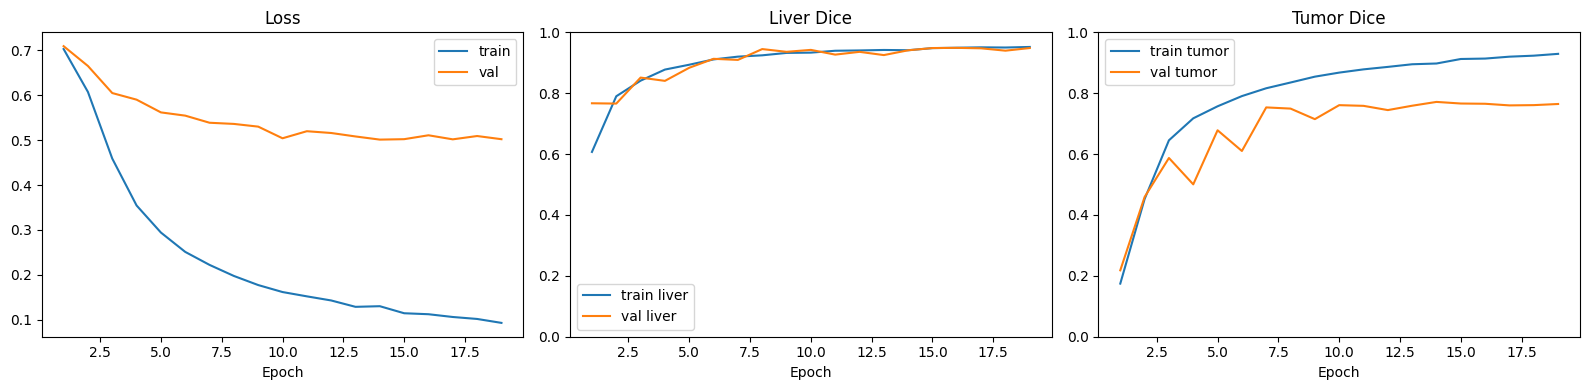

In [17]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='train')
    plt.plot(epochs, history['val_loss'], label='val')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_liver'], label='train liver')
    plt.plot(epochs, history['val_liver'], label='val liver')
    plt.title('Liver Dice')
    plt.xlabel('Epoch')
    plt.ylim(0, 1)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['train_tumor'], label='train tumor')
    plt.plot(epochs, history['val_tumor'], label='val tumor')
    plt.title('Tumor Dice')
    plt.xlabel('Epoch')
    plt.ylim(0, 1)
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_history(history)

## Final Test Evaluation

- **Purpose:** Evaluate the best saved model on the held-out test set.
- **What this cell does:**
  - Reloads the best checkpoint.
  - Tunes inference thresholds on the validation set if enabled.
  - Runs final test evaluation with test-time augmentation and post-processing.
  - Saves a JSON summary of the final test results.
- **Why this matters:** This cell produces the main quantitative results for the final submission.


In [18]:
best_model = BaselineAttentionUNet().to(DEVICE) if MODEL_VARIANT == 'baseline' else DependencyAttentionUNet().to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

if VAL_INFERENCE_TUNING:
    inference_params = tune_inference_params(best_model, val_loader, criterion, device=DEVICE)
elif os.path.exists(best_inference_path):
    with open(best_inference_path, 'r') as f:
        inference_params = json.load(f)
else:
    inference_params = {'tumor_threshold': 0.32, 'liver_threshold': 0.45, 'min_tumor_pixels': 8}

test_loss, test_scores, test_phase_weights = evaluate_with_tta(
    best_model,
    test_loader,
    criterion,
    device=DEVICE,
    inference_params=inference_params,
)

print('=' * 60)
print(f'  HARVARD {MODEL_VARIANT.upper()} RESULTS  (Test Set, Tuned TTA + Post-Processing)')
print('=' * 60)
print(f'  Test Loss  : {test_loss:.4f}')
print(f'  Liver DSC  : {test_scores["liver"]:.4f}')
print(f'  Tumor DSC  : {test_scores["tumor"]:.4f}')
print(f'  Liver thr  : {inference_params.get("liver_threshold", 0.45):.2f}')
print(f'  Tumor thr  : {inference_params["tumor_threshold"]:.2f}')
print(f'  Min tumor  : {inference_params["min_tumor_pixels"]} px')
print('=' * 60)

if test_phase_weights is not None:
    print('\nPhase Importance (avg gate activation on test set):')
    total_w = sum(test_phase_weights) + 1e-8
    for phase, weight in zip(PHASE_ORDER, test_phase_weights):
        bar = '#' * int((weight / total_w) * 40)
        print(f'  {phase.upper():3s}: {weight:.4f}  {bar}')
    print()

summary = {
    'model_variant': MODEL_VARIANT,
    'experiment_tag': EXPERIMENT_TAG,
    'test_loss': float(test_loss),
    'test_liver_dice': float(test_scores['liver']),
    'test_tumor_dice': float(test_scores['tumor']),
    'inference_params': inference_params,
    'test_phase_weights': {p: float(w) for p, w in zip(PHASE_ORDER, test_phase_weights)} if test_phase_weights else None,
    'train_patients': train_patients,
    'val_patients': val_patients,
    'test_patients': test_patients,
}
summary_path = os.path.join(ARTIFACT_DIR, f'test_summary_google100_{MODEL_VARIANT}_{EXPERIMENT_TAG}.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print('Summary saved to:', summary_path)


Best validation inference params: {'tumor_threshold': 0.24, 'liver_threshold': 0.5, 'min_tumor_pixels': 32, 'val_loss': 0.499083177539809, 'val_liver_dice': 0.9454574132492259, 'val_tumor_dice': 0.7780769455093505, 'score': 0.8366601092183068}


  HARVARD DEPENDENCY RESULTS  (Test Set, Tuned TTA + Post-Processing)
  Test Loss  : 0.4877
  Liver DSC  : 0.9435
  Tumor DSC  : 0.6975
  Liver thr  : 0.50
  Tumor thr  : 0.24
  Min tumor  : 32 px

Phase Importance (avg gate activation on test set):
  NC : 0.6709  ##########
  AP : 0.5903  #########
  PVP: 0.6134  #########
  DP : 0.6291  ##########

Summary saved to: /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/training_artifacts/test_summary_google100_dependency_p100_25d_liver_constrained_v3.json


### Phase Dependency Combination Analysis

- **Purpose:** Measure how strongly the trained model depends on different CT phase combinations.
- **What this cell does:**
  - Keeps the trained model fixed.
  - Masks out selected phases at inference time.
  - Evaluates all single-phase, two-phase, three-phase, and four-phase combinations.
  - Saves a structured summary of the dependency results.
- **Why this matters:** This analysis supports the notebook’s claim that phase interactions are important and interpretable.


In [19]:
# PHASE_DEPENDENCY_ANALYSIS_CELL
from itertools import combinations

def apply_phase_subset(images, present, keep_phases):
    """Zero unavailable phase channels and mark them absent in the phase-present vector."""
    keep_phases = set(keep_phases)
    phase_to_idx = {phase: i for i, phase in enumerate(PHASE_ORDER)}
    masked_images = images.clone()
    masked_present = present.clone()
    channels_per_phase = max(1, masked_images.shape[1] // max(len(PHASE_ORDER), 1))

    for phase, phase_idx in phase_to_idx.items():
        if phase not in keep_phases:
            start = phase_idx * channels_per_phase
            end = start + channels_per_phase
            masked_images[:, start:end] = 0.0
            masked_present[:, phase_idx] = 0.0
    return masked_images, masked_present


@torch.no_grad()
def evaluate_phase_subset(model, loader, criterion, keep_phases, inference_params, device=DEVICE, use_tta=True):
    model.eval()
    total_loss = 0.0
    metric_sums = empty_metric_sums()
    phase_weight_sums = np.zeros(len(PHASE_ORDER), dtype=np.float64)
    phase_weight_count = 0

    for batch in tqdm(loader, desc="Phase subset " + "+".join([p.upper() for p in keep_phases]), leave=False):
        x = batch["image"].to(device)
        y = batch["mask"].to(device)
        present = batch["present"].to(device)
        x, present = apply_phase_subset(x, present, keep_phases)

        if use_tta:
            probs, out = predict_probs_tta(model, x, present)
            logits_for_loss = torch.log(torch.clamp(probs, min=1e-7))
        else:
            out = model(x, present=present)
            logits = out["logits"] if isinstance(out, dict) else out
            probs = F.softmax(logits, dim=1)
            logits_for_loss = logits

        loss = criterion(logits_for_loss, y)
        total_loss += loss.item()
        preds = decode_probs(
            probs,
            tumor_threshold=inference_params.get("tumor_threshold", 0.32),
            liver_threshold=inference_params.get("liver_threshold", 0.45),
            min_tumor_pixels=inference_params.get("min_tumor_pixels", 8),
        )
        update_metric_sums_from_prediction(preds, y, metric_sums)

        if isinstance(out, dict) and "phase_weights" in out:
            phase_weight_sums += out["phase_weights"].detach().cpu().numpy()
            phase_weight_count += 1

    scores = finalize_metric_sums(metric_sums)
    phase_weights = (phase_weight_sums / max(phase_weight_count, 1)).tolist() if phase_weight_count > 0 else None
    return {
        "phases": list(keep_phases),
        "phase_label": "+".join([p.upper() for p in keep_phases]),
        "n_phases": len(keep_phases),
        "loss": float(total_loss / max(len(loader), 1)),
        "liver_dice": float(scores["liver"]),
        "tumor_dice": float(scores["tumor"]),
        "phase_weights": {p: float(w) for p, w in zip(PHASE_ORDER, phase_weights)} if phase_weights else None,
    }


phase_dependency_results = []
for n_phases in range(1, len(PHASE_ORDER) + 1):
    for combo in combinations(PHASE_ORDER, n_phases):
        phase_dependency_results.append(
            evaluate_phase_subset(
                best_model,
                test_loader,
                criterion,
                keep_phases=combo,
                inference_params=inference_params,
                device=DEVICE,
                use_tta=True,
            )
        )

best_dependency_rows = []
row_names = {
    1: "Best single phase",
    2: "Best two-phase combo",
    3: "Best three-phase combo",
    4: "All four phases",
}
for n_phases in range(1, len(PHASE_ORDER) + 1):
    candidates = [r for r in phase_dependency_results if r["n_phases"] == n_phases]
    if n_phases == len(PHASE_ORDER):
        best_row = next(r for r in candidates if r["phases"] == PHASE_ORDER)
    else:
        best_row = max(candidates, key=lambda r: r["tumor_dice"])
    best_dependency_rows.append({"setting": row_names[n_phases], **best_row})

print("=" * 86)
print("  ALL PHASE COMBINATIONS  (Fixed trained model, test set)")
print("=" * 86)
print(f"{"#":>2s} {"Input phases":22s} {"N":>2s} {"Liver DSC":>10s} {"Tumor DSC":>10s}")
print("-" * 86)
phase_order_rank = {phase: i for i, phase in enumerate(PHASE_ORDER)}
ranked_all_combinations = sorted(
    phase_dependency_results,
    key=lambda r: (r["n_phases"], [phase_order_rank[p] for p in r["phases"]]),
)
for idx, row in enumerate(ranked_all_combinations, start=1):
    print(f"{idx:2d} {row["phase_label"]:22s} {row["n_phases"]:2d} {row["liver_dice"]:10.4f} {row["tumor_dice"]:10.4f}")
print("=" * 86)

print("\n" + "=" * 86)
print("  BEST PHASE COMBINATION SUMMARY")
print("=" * 86)
print(f"{"Setting":24s} {"Input phases":22s} {"Liver DSC":>10s} {"Tumor DSC":>10s}")
print("-" * 86)
for row in best_dependency_rows:
    print(f"{row["setting"]:24s} {row["phase_label"]:22s} {row["liver_dice"]:10.4f} {row["tumor_dice"]:10.4f}")
print("=" * 86)

print("\nAll phase combinations ranked by tumor DSC:")
for row in sorted(phase_dependency_results, key=lambda r: r["tumor_dice"], reverse=True):
    print(f"{row["phase_label"]:22s} | liver {row["liver_dice"]:.4f} | tumor {row["tumor_dice"]:.4f}")

phase_dependency_summary = {
    "analysis_type": "inference_time_phase_combination_dependency",
    "note": "The trained full multiphase model is fixed; unavailable phases are zeroed and marked absent at inference time.",
    "best_rows": best_dependency_rows,
    "all_combinations": phase_dependency_results,
}
phase_dependency_path = os.path.join(ARTIFACT_DIR, f"phase_dependency_combinations_{MODEL_VARIANT}_{EXPERIMENT_TAG}.json")
with open(phase_dependency_path, "w") as f:
    json.dump(phase_dependency_summary, f, indent=2)
print("\nPhase dependency summary saved to:", phase_dependency_path)


  ALL PHASE COMBINATIONS  (Fixed trained model, test set)
 # Input phases            N  Liver DSC  Tumor DSC
--------------------------------------------------------------------------------------
 1 NC                      1     0.9183     0.1857
 2 AP                      1     0.9320     0.3113
 3 PVP                     1     0.9530     0.3353
 4 DP                      1     0.9372     0.1935
 5 NC+AP                   2     0.9356     0.5696
 6 NC+PVP                  2     0.9367     0.7137
 7 NC+DP                   2     0.9212     0.5655
 8 AP+PVP                  2     0.9456     0.6863
 9 AP+DP                   2     0.9399     0.6635
10 PVP+DP                  2     0.9322     0.7209
11 NC+AP+PVP               3     0.9459     0.6887
12 NC+AP+DP                3     0.9400     0.6394
13 NC+PVP+DP               3     0.9344     0.6985
14 AP+PVP+DP               3     0.9440     0.7109
15 NC+AP+PVP+DP            4     0.9435     0.6975

  BEST PHASE COMBINATION SUMMARY
Setti

## Publication-Ready Figures

- **Purpose:** Create clean figures for the report, paper, or presentation.
- **What this cell does:**
  - Saves plots for training dynamics, final Dice scores, and phase importance.
  - Saves figures for the phase-combination study and qualitative prediction examples.
  - Stores a figure manifest for easy export and reference.
- **Why this matters:** These visuals communicate the final results clearly and professionally.


Saved figure: /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/training_artifacts/paper_figures/fig1_training_dynamics.png


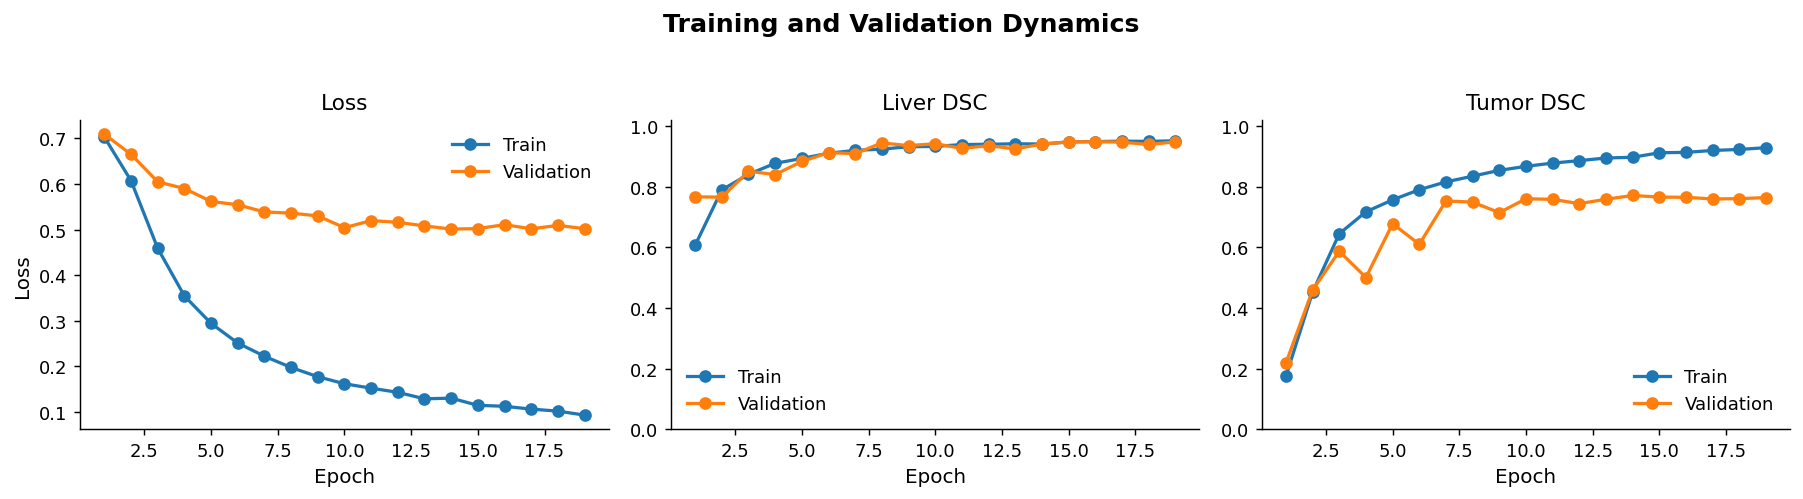

Saved figure: /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/training_artifacts/paper_figures/fig2_test_dsc_summary.png


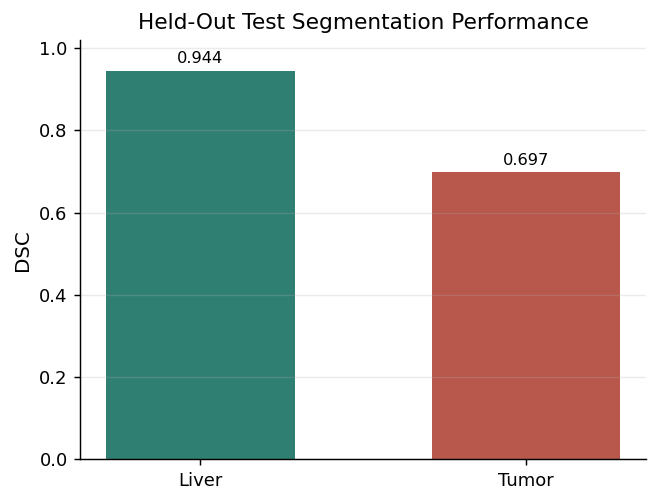

Saved figure: /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/training_artifacts/paper_figures/fig3_phase_gate_importance.png


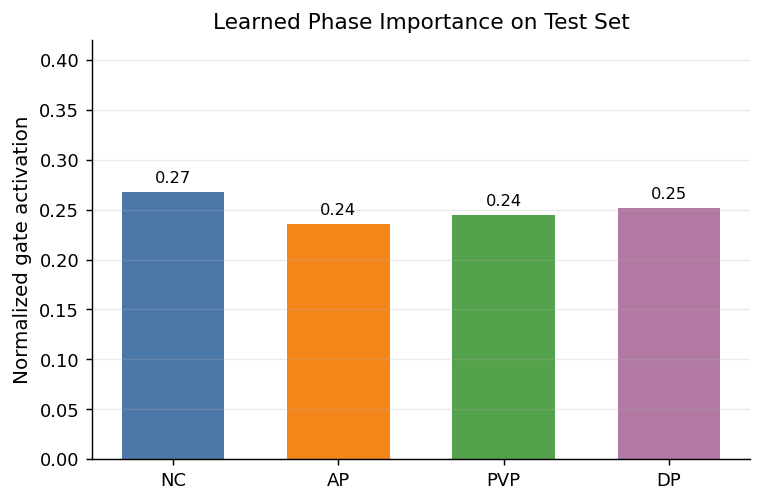

Saved figure: /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/training_artifacts/paper_figures/fig4_all_phase_combinations_tumor_dsc.png


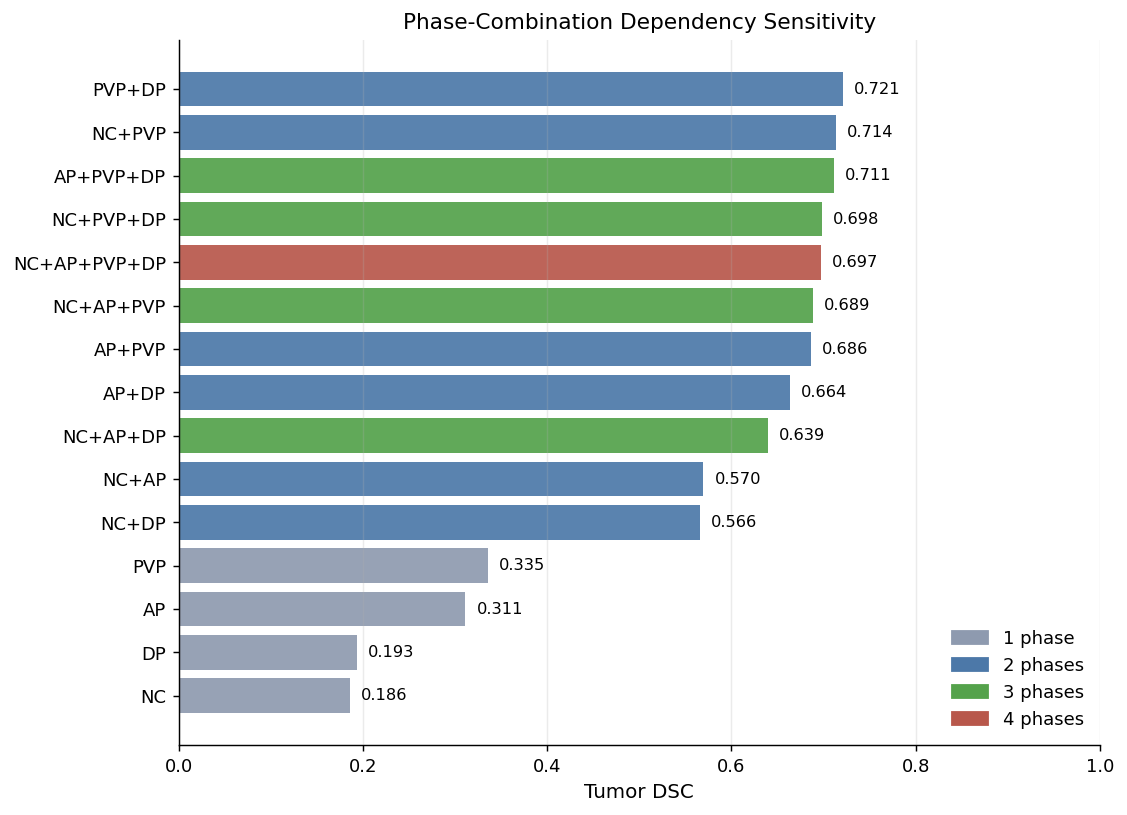

Saved figure: /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/training_artifacts/paper_figures/fig5_best_phase_subset_summary.png


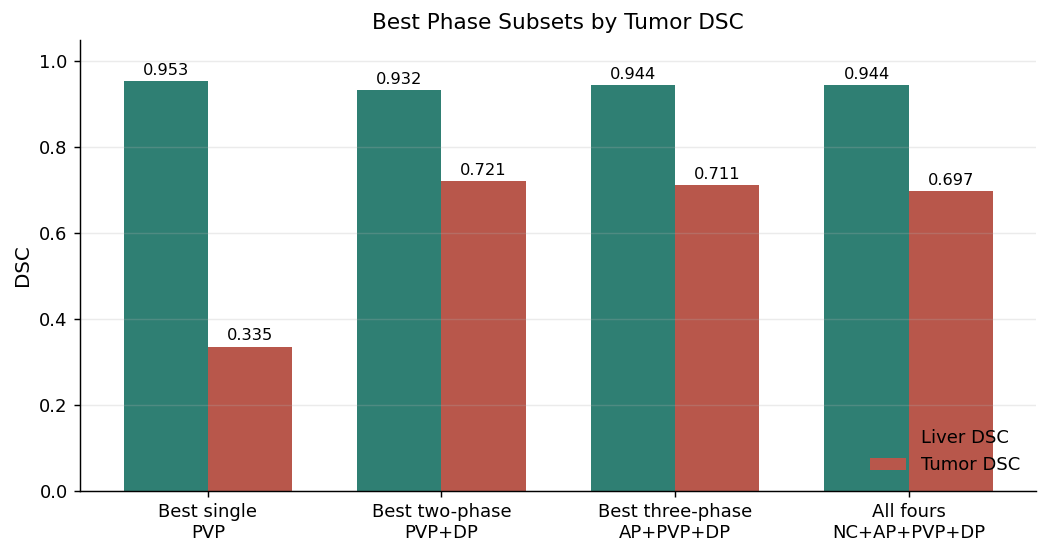

Saved figure: /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/training_artifacts/paper_figures/fig6_qualitative_predictions.png


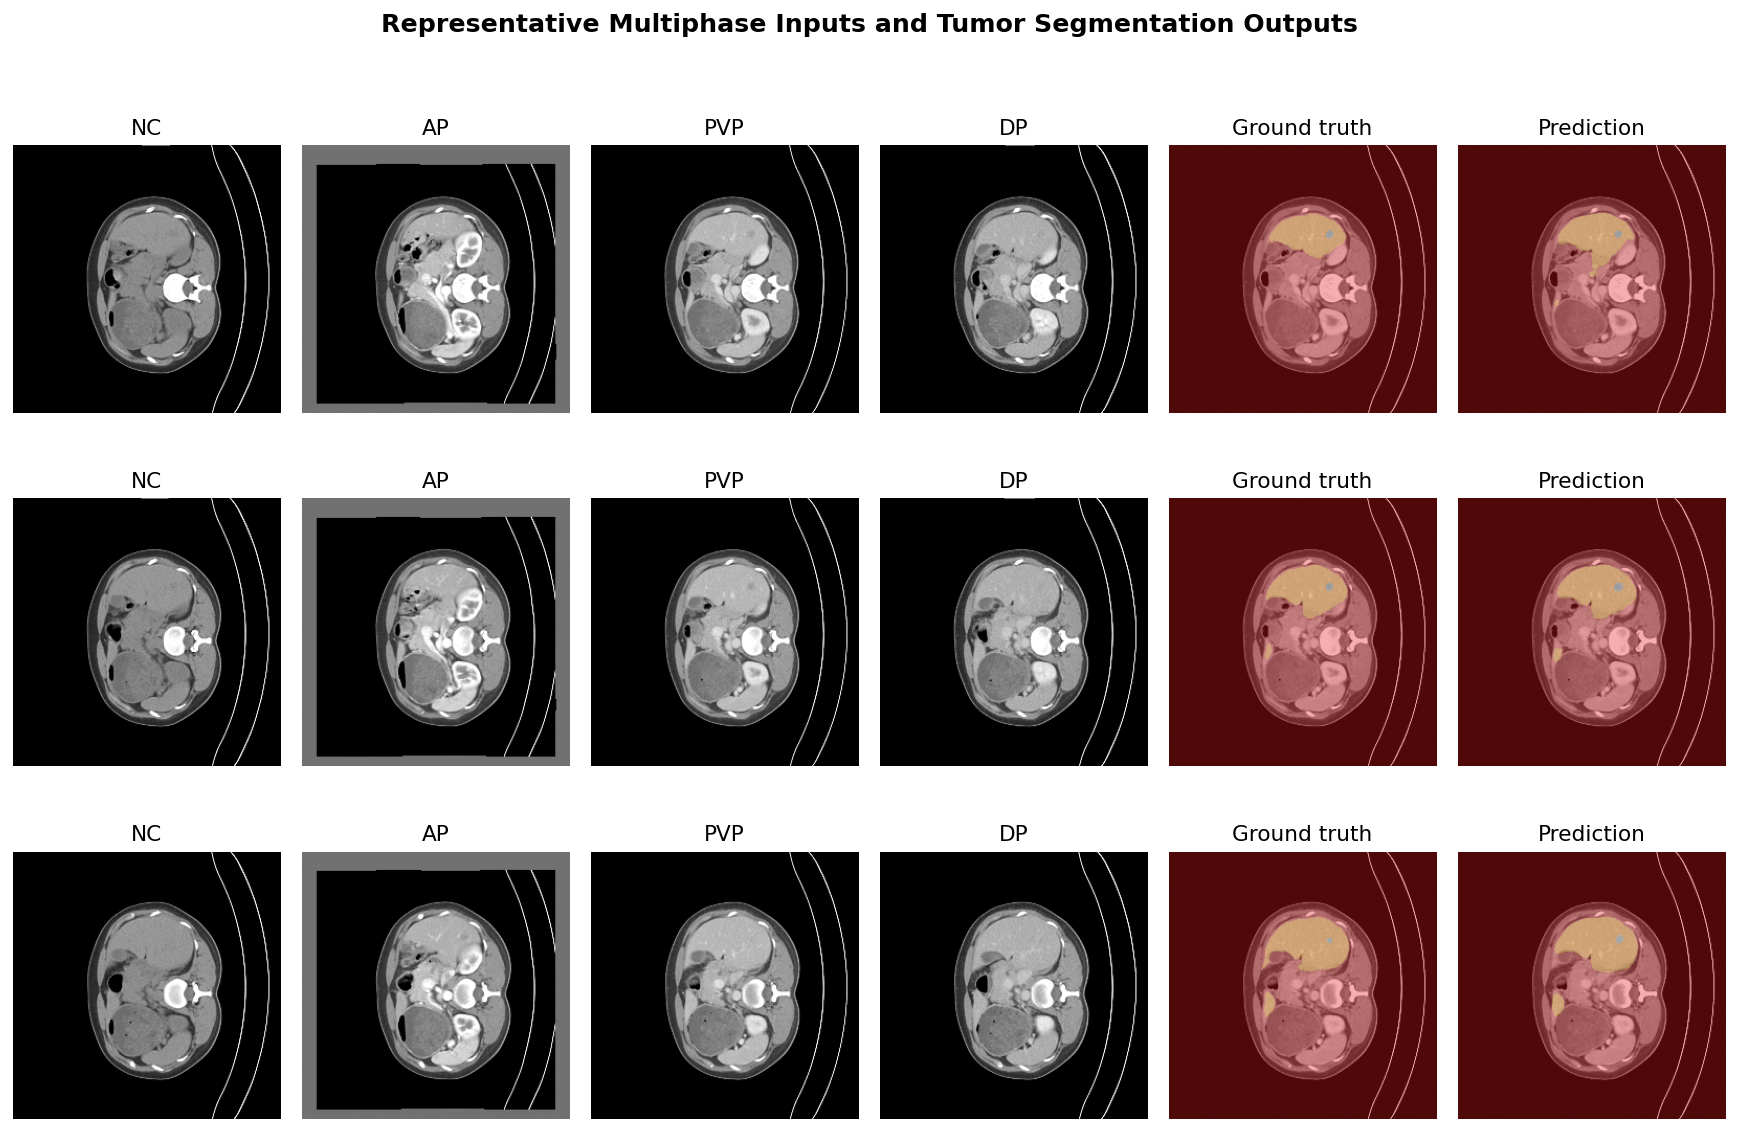

Paper figure manifest saved to: /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/training_artifacts/paper_figures/paper_figure_manifest.json


In [20]:
# PUBLICATION_FIGURES_CELL
FIGURE_DIR = os.path.join(ARTIFACT_DIR, 'paper_figures')
Path(FIGURE_DIR).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIGURE_MANIFEST = []


def save_paper_figure(fig, name):
    png_path = os.path.join(FIGURE_DIR, f'{name}.png')
    pdf_path = os.path.join(FIGURE_DIR, f'{name}.pdf')
    fig.savefig(png_path, bbox_inches='tight', facecolor='white')
    fig.savefig(pdf_path, bbox_inches='tight', facecolor='white')
    FIGURE_MANIFEST.append({'name': name, 'png': png_path, 'pdf': pdf_path})
    print('Saved figure:', png_path)
    return png_path, pdf_path


def annotate_bars(ax, bars, fmt='{:.3f}', pad=0.012):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + pad,
            fmt.format(height),
            ha='center',
            va='bottom',
            fontsize=9,
        )


# Figure 1: training dynamics.
epochs = np.arange(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.7))
axes[0].plot(epochs, history['train_loss'], marker='o', linewidth=1.8, label='Train')
axes[0].plot(epochs, history['val_loss'], marker='o', linewidth=1.8, label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(frameon=False)

axes[1].plot(epochs, history['train_liver'], marker='o', linewidth=1.8, label='Train')
axes[1].plot(epochs, history['val_liver'], marker='o', linewidth=1.8, label='Validation')
axes[1].set_title('Liver DSC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1.02)
axes[1].legend(frameon=False)

axes[2].plot(epochs, history['train_tumor'], marker='o', linewidth=1.8, label='Train')
axes[2].plot(epochs, history['val_tumor'], marker='o', linewidth=1.8, label='Validation')
axes[2].set_title('Tumor DSC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1.02)
axes[2].legend(frameon=False)
fig.suptitle('Training and Validation Dynamics', y=1.03, fontsize=14, fontweight='bold')
fig.tight_layout()
save_paper_figure(fig, 'fig1_training_dynamics')
plt.show()


# Figure 2: final held-out test performance.
metric_names = ['Liver', 'Tumor']
metric_values = [summary['test_liver_dice'], summary['test_tumor_dice']]
fig, ax = plt.subplots(figsize=(5.2, 4.0))
bars = ax.bar(metric_names, metric_values, color=['#2f7f73', '#b8574b'], width=0.58)
annotate_bars(ax, bars)
ax.set_ylim(0, 1.02)
ax.set_ylabel('DSC')
ax.set_title('Held-Out Test Segmentation Performance')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
save_paper_figure(fig, 'fig2_test_dsc_summary')
plt.show()


# Figure 3: learned phase gate activations.
if summary.get('test_phase_weights'):
    phase_labels = [p.upper() for p in PHASE_ORDER]
    raw_weights = np.array([summary['test_phase_weights'][p] for p in PHASE_ORDER], dtype=float)
    normalized_weights = raw_weights / max(raw_weights.sum(), 1e-8)

    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    bars = ax.bar(phase_labels, normalized_weights, color=['#4c78a8', '#f58518', '#54a24b', '#b279a2'], width=0.62)
    annotate_bars(ax, bars, fmt='{:.2f}', pad=0.006)
    ax.set_ylim(0, max(0.42, normalized_weights.max() + 0.08))
    ax.set_ylabel('Normalized gate activation')
    ax.set_title('Learned Phase Importance on Test Set')
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    save_paper_figure(fig, 'fig3_phase_gate_importance')
    plt.show()
else:
    print('Skipping phase gate figure: no test_phase_weights available in summary.')


# Figure 4: all 15 phase-combination dependency results.
combo_rows = sorted(phase_dependency_results, key=lambda r: r['tumor_dice'])
combo_labels = [r['phase_label'] for r in combo_rows]
tumor_values = [r['tumor_dice'] for r in combo_rows]
liver_values = [r['liver_dice'] for r in combo_rows]
n_phase_values = [r['n_phases'] for r in combo_rows]
phase_count_colors = {1: '#8e9aaf', 2: '#4c78a8', 3: '#54a24b', 4: '#b8574b'}
bar_colors = [phase_count_colors[n] for n in n_phase_values]

fig, ax = plt.subplots(figsize=(8.8, 6.4))
y_pos = np.arange(len(combo_rows))
bars = ax.barh(y_pos, tumor_values, color=bar_colors, alpha=0.92)
ax.set_yticks(y_pos)
ax.set_yticklabels(combo_labels)
ax.set_xlim(0, 1.0)
ax.set_xlabel('Tumor DSC')
ax.set_title('Phase-Combination Dependency Sensitivity')
ax.grid(axis='x', alpha=0.25)
for bar, val in zip(bars, tumor_values):
    ax.text(val + 0.012, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=9)
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=phase_count_colors[n]) for n in sorted(phase_count_colors)]
ax.legend(legend_handles, [f'{n} phase' if n == 1 else f'{n} phases' for n in sorted(phase_count_colors)], frameon=False, loc='lower right')
fig.tight_layout()
save_paper_figure(fig, 'fig4_all_phase_combinations_tumor_dsc')
plt.show()


# Figure 5: best single/two/three/all phase comparison for liver and tumor.
summary_labels = [row['setting'].replace(' combo', '').replace(' phase', '') for row in best_dependency_rows]
x = np.arange(len(best_dependency_rows))
width = 0.36
liver_best = [row['liver_dice'] for row in best_dependency_rows]
tumor_best = [row['tumor_dice'] for row in best_dependency_rows]
phase_labels = [row['phase_label'] for row in best_dependency_rows]

fig, ax = plt.subplots(figsize=(8.2, 4.4))
b1 = ax.bar(x - width / 2, liver_best, width, label='Liver DSC', color='#2f7f73')
b2 = ax.bar(x + width / 2, tumor_best, width, label='Tumor DSC', color='#b8574b')
annotate_bars(ax, b1, pad=0.008)
annotate_bars(ax, b2, pad=0.008)
ax.set_ylim(0, 1.05)
ax.set_ylabel('DSC')
ax.set_title('Best Phase Subsets by Tumor DSC')
ax.set_xticks(x)
ax.set_xticklabels([f'{label}\n{phases}' for label, phases in zip(summary_labels, phase_labels)])
ax.legend(frameon=False, loc='lower right')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
save_paper_figure(fig, 'fig5_best_phase_subset_summary')
plt.show()


# Figure 6: qualitative paper panel, saved separately from the interactive visualization below.
@torch.no_grad()
def save_publication_prediction_panel(model, dataset, num_samples=3, device=DEVICE):
    model.eval()
    tumor_idxs = []
    for idx in range(len(dataset)):
        item = dataset[idx]
        if (item['mask'] == 2).any():
            tumor_idxs.append(idx)
        if len(tumor_idxs) >= num_samples:
            break
    if not tumor_idxs:
        tumor_idxs = list(np.linspace(0, max(0, len(dataset) - 1), num=min(num_samples, len(dataset)), dtype=int))

    fig, axes = plt.subplots(len(tumor_idxs), 6, figsize=(13.5, 3.0 * len(tumor_idxs)))
    if len(tumor_idxs) == 1:
        axes = np.expand_dims(axes, axis=0)
    cmap = plt.get_cmap('Set1', 3)

    for row, idx in enumerate(tumor_idxs):
        item = dataset[idx]
        x_batch = item['image'][None].to(device)
        present = item['present'][None].to(device)
        probs, _ = predict_probs_tta(model, x_batch, present)
        pred = decode_probs(
            probs,
            tumor_threshold=inference_params.get('tumor_threshold', 0.32),
            liver_threshold=inference_params.get('liver_threshold', 0.45),
            min_tumor_pixels=inference_params.get('min_tumor_pixels', 8),
        )[0].cpu().numpy()
        gt = item['mask'].cpu().numpy()
        base_phase_channel = 2 * SLICES_PER_PHASE + SLICE_CONTEXT_RADIUS
        base_img = item['image'][base_phase_channel].cpu().numpy()

        for col, phase in enumerate(PHASE_ORDER):
            center_channel = col * SLICES_PER_PHASE + SLICE_CONTEXT_RADIUS
            axes[row, col].imshow(item['image'][center_channel].cpu().numpy(), cmap='gray')
            axes[row, col].set_title(phase.upper())
            axes[row, col].axis('off')

        axes[row, 4].imshow(base_img, cmap='gray')
        axes[row, 4].imshow(gt, cmap=cmap, alpha=0.35, vmin=0, vmax=2)
        axes[row, 4].set_title('Ground truth')
        axes[row, 4].axis('off')

        axes[row, 5].imshow(base_img, cmap='gray')
        axes[row, 5].imshow(pred, cmap=cmap, alpha=0.35, vmin=0, vmax=2)
        axes[row, 5].set_title('Prediction')
        axes[row, 5].axis('off')

    fig.suptitle('Representative Multiphase Inputs and Tumor Segmentation Outputs', y=1.01, fontsize=14, fontweight='bold')
    fig.tight_layout()
    save_paper_figure(fig, 'fig6_qualitative_predictions')
    plt.show()


save_publication_prediction_panel(best_model, test_ds, num_samples=min(3, len(test_ds)), device=DEVICE)

manifest_path = os.path.join(FIGURE_DIR, 'paper_figure_manifest.json')
with open(manifest_path, 'w') as f:
    json.dump(FIGURE_MANIFEST, f, indent=2)
print('Paper figure manifest saved to:', manifest_path)


## Baseline Comparison Context

A baseline version of this pipeline was implemented and submitted separately using the same overall multi-phase liver/tumor segmentation task, but without the proposed dependency-aware phase modeling. In that baseline, the model was a **BaselineAttentionUNet**, which processes the stacked multi-phase input through a single encoder-decoder path with attention-gated skip connections, but **does not use per-phase encoders, learned phase-specific gating, or explicit pairwise phase interaction modeling**.

By contrast, the final model in this notebook (`DependencyAttentionUNet`) preserves phase-specific representations through a shared per-phase encoder, learns an importance gate for each phase, and introduces an explicit pairwise cross-phase interaction term before decoding. This makes the final design more closely aligned with the novelty proposed in the SOA survey: moving beyond implicit multi-phase fusion toward **explicit dependency-aware phase interaction modeling**.

A baseline run was completed in a separate notebook on an earlier experimental setup and achieved lower tumor segmentation performance than the dependency-aware design. However, because that baseline was trained under different conditions, including a smaller dataset subset, earlier preprocessing and inference setup, and non-2.5D input, it should be interpreted as **supporting evidence of the architectural direction rather than as a strict controlled benchmark**. A fully rigorous quantitative comparison would require rerunning the baseline under the exact same 100-patient, 2.5D, validation-tuned setup used in this final notebook.


## Final Submission Note

This is our improved implementation (Iteration 2) — the complete multiphase liver/tumor segmentation pipeline submitted as the final deliverable.

**Pipeline and Data:**
- Automatically falls back to existing `processed_cache*` NPZ slices if raw Drive archives are not visible
- 100 Harvard TAR files, all four CT phases (NC, AP, PVP, DP)
- Multi-class segmentation: 0=background, 1=liver, 2=tumor
- Patient-wise train/val/test split (no data leakage)
- Cache manifest versioning (stale cache detection)
- Tumor-positive oversampling (dynamic weight, capped at 16.0 and at least 12.0)
- 2.5D input: 3 neighboring slices per phase, with max 96 tumor slices plus adjacent liver context

**Model: DependencyAttentionUNet (active)**
- Per-phase encoder with learned attention gate per phase
- Pairwise cross-phase interaction module for explicit dependency modeling
- Phase dropout during training (p=0.03) as light multiphase regularization
- Explicit per-phase gate activations returned as `phase_weights`
- Phase dependency combination analysis evaluates which phase subsets contribute most to tumor segmentation

**Training:**
- Combined focal CE + tumor-biased Dice + tumor focal Tversky loss
- Checkpoint selected by 0.35*liver + 0.65*tumor validation DSC with early stopping
- Single patient-wise train/validation/test split using `SEED=42` for the final submitted result
- Up to 24 training epochs with early stopping and stronger weight decay
- Gate collapse prevention (minimum gate activation 0.15)
- Validation-tuned tumor probability threshold avoids hard argmax under-calling
- Larger per-phase encoder: base_features=[64,128,256]

**Inference:**
- Test-time augmentation: horizontal-flip softmax averaging with validation-tuned liver and tumor thresholds
- Post-processing: validation-tuned small-component filtering and liver fill
- Explicit phase importance scores and phase-combination dependency results printed and saved with test results

**SOA Alignment:**
- Explicit cross-phase dependency modeling (per-phase gates + pairwise interactions)
- Interpretable phase contribution scores and phase-combination sensitivity analysis aligned with radiological priors
- Baseline vs. dependency comparison supported via MODEL_VARIANT flag


## Download Paper Figures

- **Purpose:** Package the generated figures for easy download from Colab.
- **What this cell does:**
  - Collects the saved figure files.
  - Creates a ZIP archive.
  - Starts a Colab download when supported.
- **Why this matters:** This is the final convenience step for exporting the paper-ready visuals.


In [22]:
# DOWNLOAD_PAPER_FIGURES_CELL
import shutil

figure_dir = os.path.join(ARTIFACT_DIR, 'paper_figures')
zip_base = os.path.join(ARTIFACT_DIR, 'paper_figures')
zip_path = zip_base + '.zip'

if not os.path.isdir(figure_dir):
    raise RuntimeError(f'Figure directory not found: {figure_dir}. Run the Publication-Ready Figures cell first.')

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(zip_base, 'zip', figure_dir)
print('Paper figures zipped to:', zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print('Automatic Colab download was not available:', e)
    print('You can manually download this file from the Colab file browser:')
    print(zip_path)


Paper figures zipped to: /content/harvard_multiphase_work/processed_cache_100_multiclass_25d_liver_constrained_v3/training_artifacts/paper_figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>